In [14]:
# 1. Instalacja pakietów
#!pip install kagglehub xgboost catboost lightgbm shap imbalanced-learn statsmodels graphviz

In [15]:
# 2. Import bibliotek
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from IPython.display import display

In [16]:
# 3. Pobranie danych z KaggleHub
import kagglehub
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\kamil\.cache\kagglehub\datasets\laotse\credit-risk-dataset\versions\1


In [17]:
# 4. Wczytanie danych
df = pd.read_csv(os.path.join(path, "credit_risk_dataset.csv"))

In [18]:
# 5.1 Wstępny podgląd
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe(include='all'))
print(df['loan_status'].value_counts(normalize=True))

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [19]:
# 5.2 Dalszy podgląd danych
print("**Pierwsze 5 wierszy:**")
display(df.head().style.set_properties(**{'background-color': '#f9f9f9', 
                                          'color': '#333',
                                          'border': '1px solid #ddd',
                                          'text-align': 'center'}))

print("**Informacje o DataFrame:**")
df_info = df.info()  # Nie można stylizować, ale można przekazać użytkownikowi


print("**Liczba brakujących wartości:**")
display(pd.DataFrame(df.isnull().sum(), columns=['Braki']).style.set_properties(**{'color': '#d9534f'}))


**Pierwsze 5 wierszy:**


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000000,PERSONAL,D,35000,16.020000,1,0.590000,Y,3
1,21,9600,OWN,5.000000,EDUCATION,B,1000,11.140000,0,0.100000,N,2
2,25,9600,MORTGAGE,1.000000,MEDICAL,C,5500,12.870000,1,0.570000,N,3
3,23,65500,RENT,4.000000,MEDICAL,C,35000,15.230000,1,0.530000,N,2
4,24,54400,RENT,8.000000,MEDICAL,C,35000,14.270000,1,0.550000,Y,4


**Informacje o DataFrame:**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
**L

,Braki
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


c:\Users\kamil\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\kamil\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\kamil\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\kamil\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

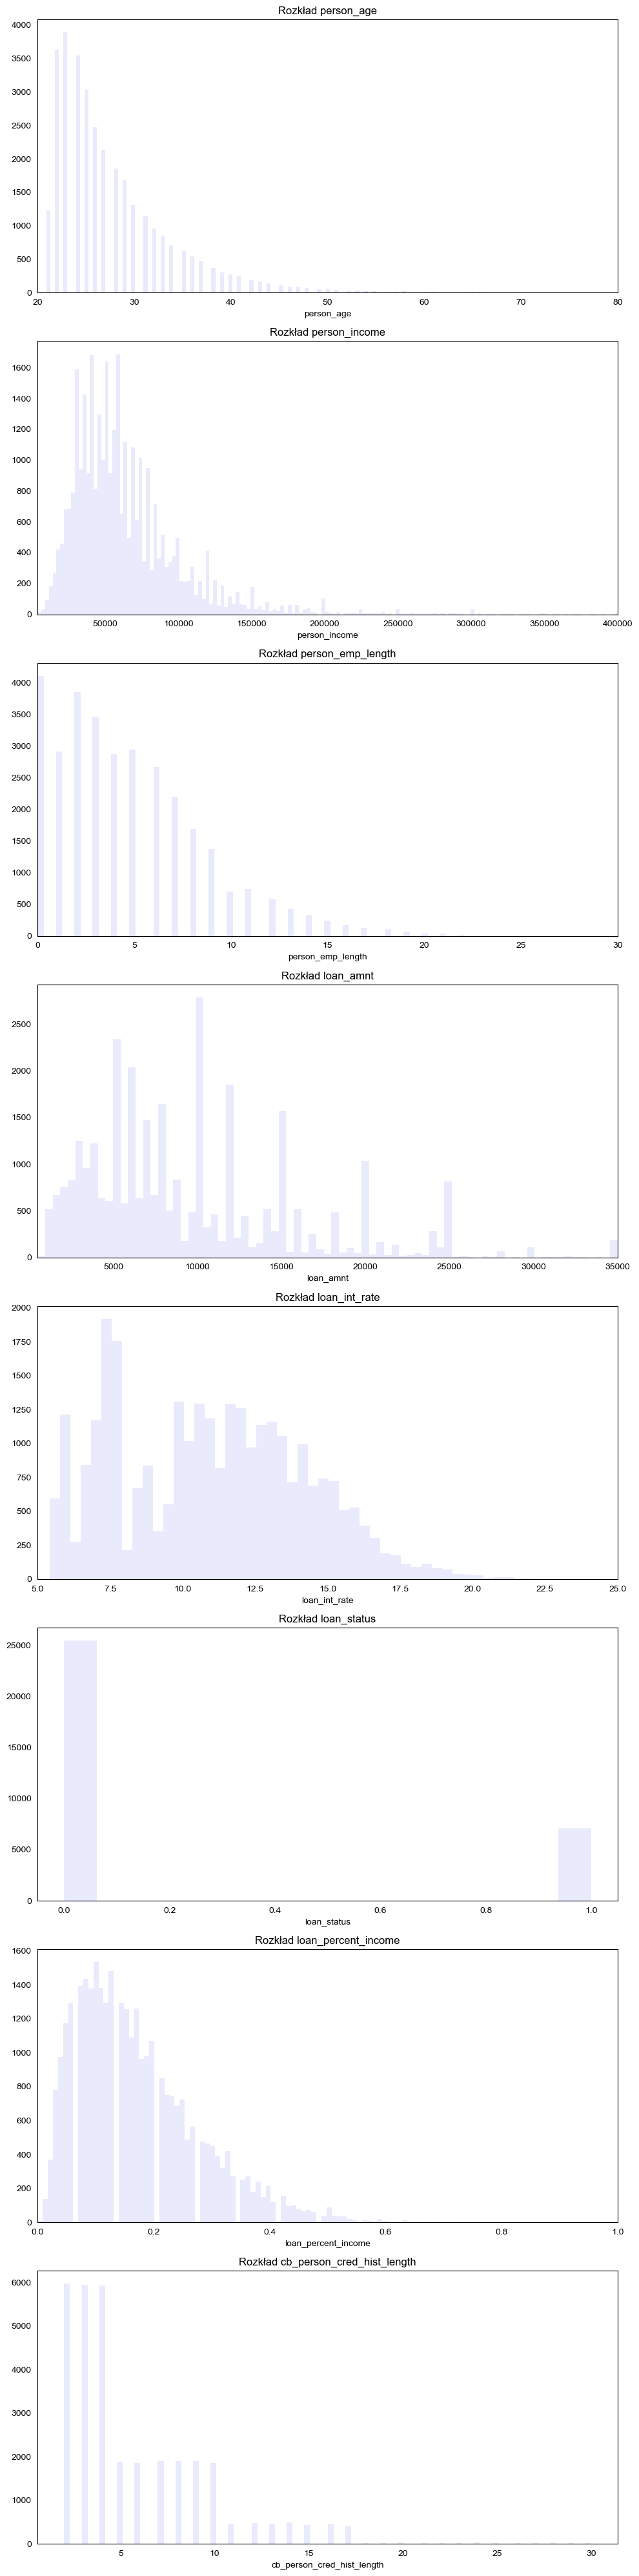

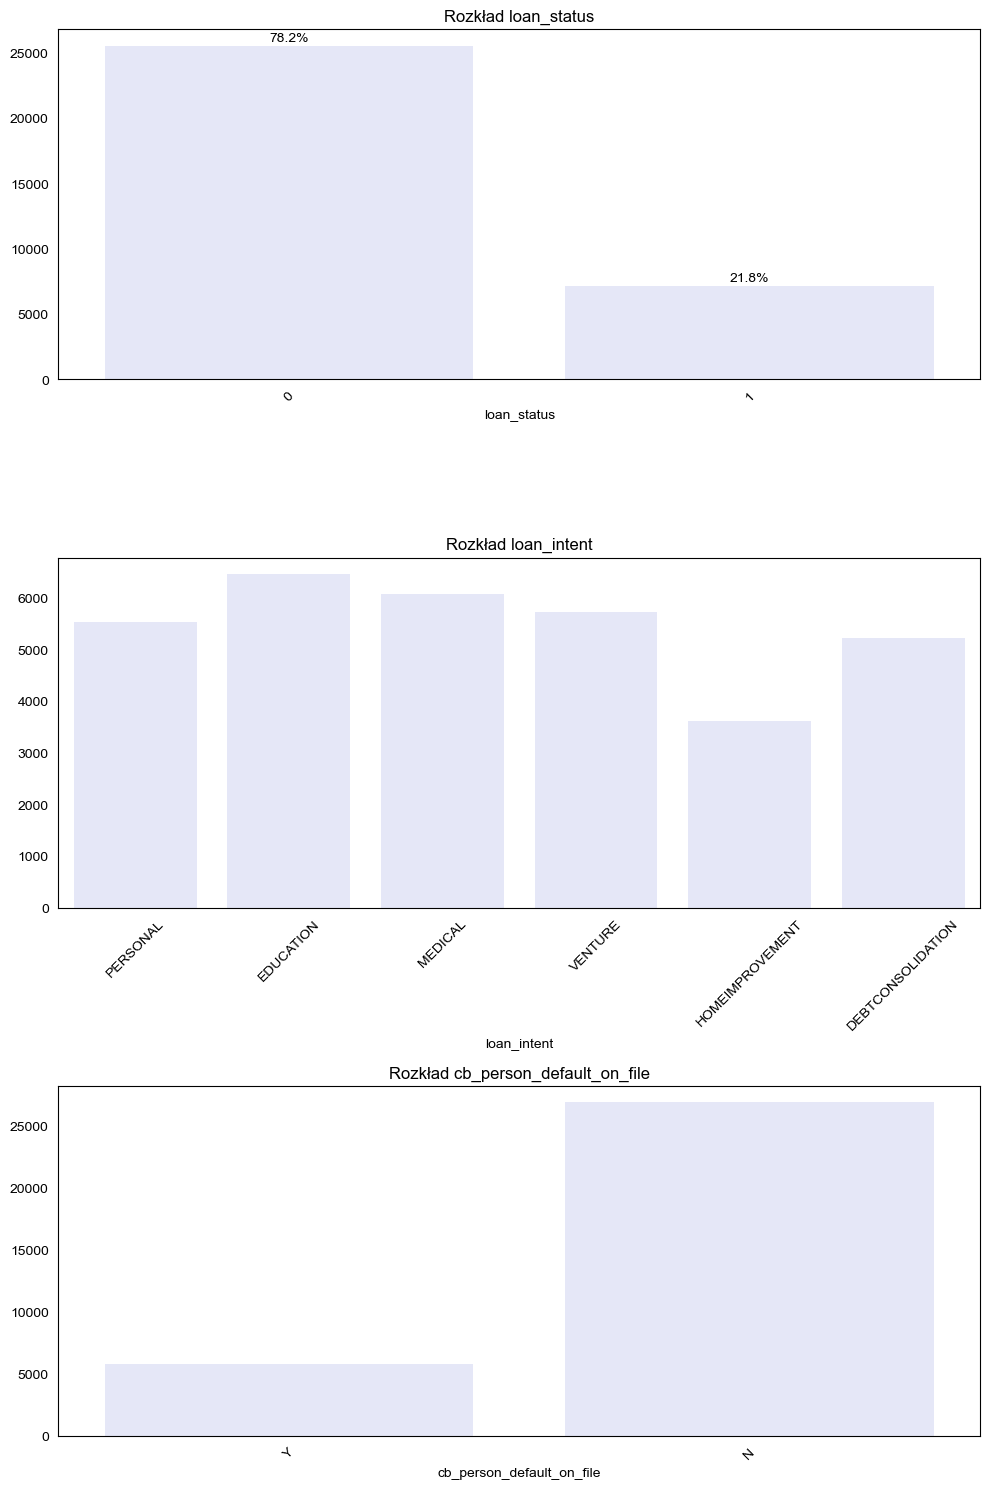

In [20]:
# 5.2. Rozkłady zmiennych 

import matplotlib.pyplot as plt
import seaborn as sns

figure_bg  = (1.0, 1.0, 1.0)                   # białe tło figury
axes_bg    = (1.0, 1.0, 1.0)                   # białe tło osi
fill_color = (226/255, 228/255, 250/255)       # jasnofioletowe słupki
black      = 'black'


sns.set_style("white")
plt.rcParams['figure.facecolor'] = figure_bg
plt.rcParams['axes.facecolor']   = axes_bg
plt.rcParams.update({
    'text.color':      black,
    'axes.labelcolor': black,
    'xtick.color':     black,
    'ytick.color':     black,
    'axes.titlecolor': black
})

# ---- HISTOGRAMY (zmienne liczbowe) ----
num_cols = df.select_dtypes(include='number').columns
num_vars = {
    "person_age": (20, 80),
    "person_income": (4000, 400000),
    "person_emp_length": (0, 30),
    "loan_amnt": (500, 35000),
    "loan_int_rate": (5, 25),
    "loan_percent_income": (0, 1)
}

fig, axes = plt.subplots(
    nrows=len(num_cols), ncols=1,
    figsize=(10, 5 * len(num_cols)),
    facecolor=figure_bg
)

for ax, col in zip(axes, num_cols):
    ax.set_facecolor(axes_bg)
    sns.histplot(
        data=df, x=col,
        element='bars',
        fill=True,
        color=fill_color,
        edgecolor=fill_color,
        linewidth=0,
        ax=ax
    )

    for spine in ax.spines.values():
        spine.set_color(black)
    ax.tick_params(axis='x', colors=black)
    ax.tick_params(axis='y', colors=black)

    ax.set_title(f'Rozkład {col}')
    ax.set_ylabel('')
    if col in num_vars:
        ax.set_xlim(num_vars[col])

plt.tight_layout()
plt.show()


# ---- SŁUPKI (zmienne kategoryczne) ----
categorical_cols = ['loan_status', 'loan_intent', 'cb_person_default_on_file']
fig, axes = plt.subplots(
    nrows=len(categorical_cols), ncols=1,
    figsize=(10, 5 * len(categorical_cols)),
    facecolor=figure_bg
)

total = len(df)
for ax, col in zip(axes, categorical_cols):
    ax.set_facecolor(axes_bg)
    sns.countplot(
        data=df, x=col,
        color=fill_color,
        edgecolor=fill_color,
        linewidth=0,
        ax=ax
    )
    if col == 'loan_status':
        for p in ax.patches:
            height = p.get_height()
            pct = height / total * 100
            ax.text(
                x=p.get_x() + p.get_width() / 2,
                y=height + total * 0.005,
                s=f'{pct:.1f}%',
                ha='center',
                va='bottom',
                color=black
            )
    for spine in ax.spines.values():
        spine.set_color(black)
    ax.tick_params(axis='x', rotation=45, colors=black)
    ax.tick_params(axis='y', colors=black)
    ax.set_title(f'Rozkład {col}')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()



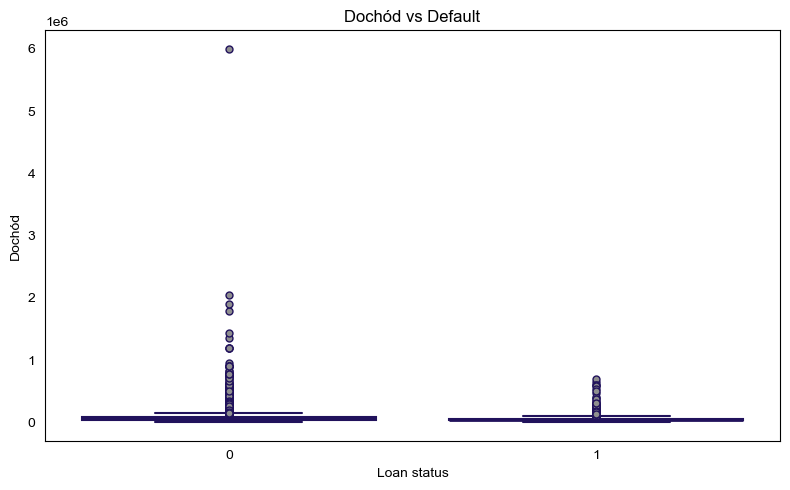

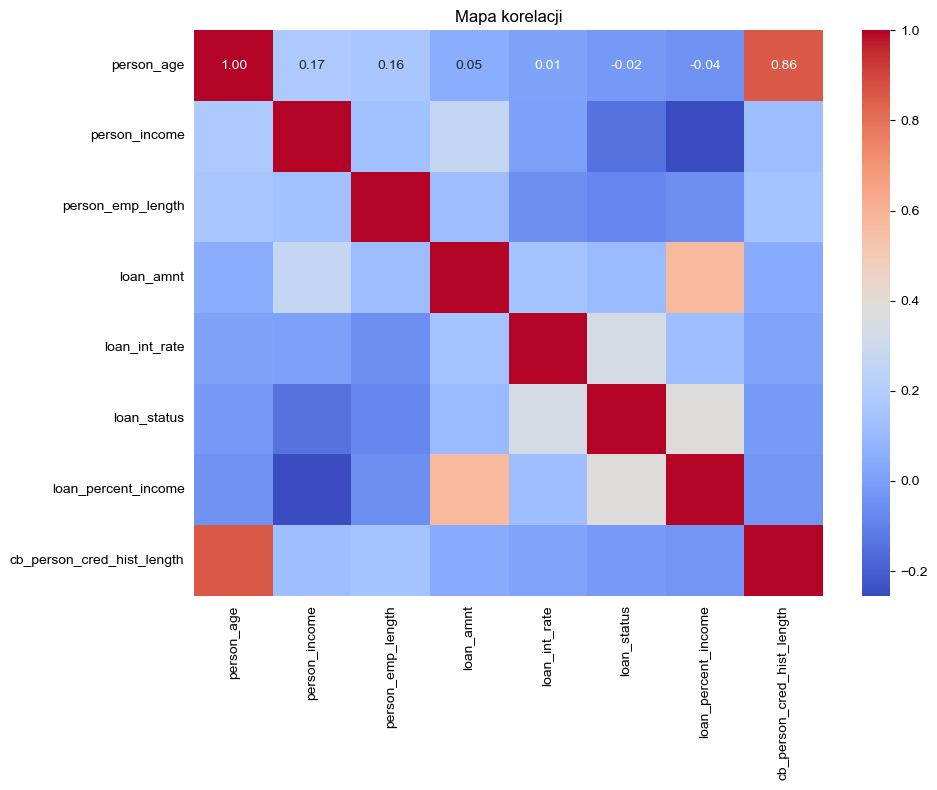

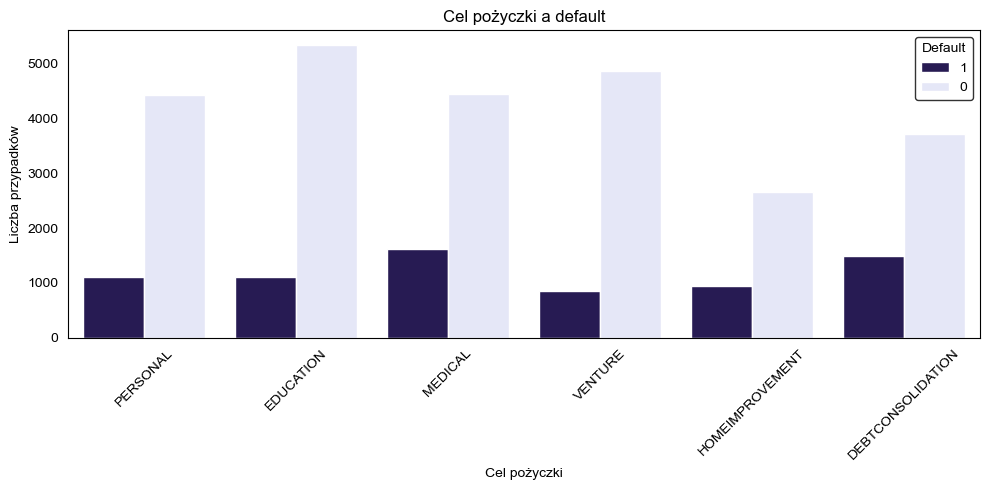

In [21]:
# 6. Wizualizacje
import matplotlib.pyplot as plt
import seaborn as sns
line_color = (33/255, 18/255, 92/255)        

# 1) Boxplot
fig, ax = plt.subplots(figsize=(8, 5), facecolor=figure_bg)
ax.set_facecolor(axes_bg)

sns.boxplot(
    x='loan_status',
    y='person_income',
    data=df,
    ax=ax,
    palette=[fill_color, fill_color],           # oba pudełka w jasnym fiolecie
    boxprops=dict(facecolor=fill_color, color=line_color),
    whiskerprops=dict(color=line_color),
    capprops=dict(color=line_color),
    medianprops=dict(color=line_color, linewidth=2),
    flierprops=dict(marker='o', markeredgecolor=line_color)
)

ax.set_title('Dochód vs Default')
ax.set_xlabel('Loan status')
ax.set_ylabel('Dochód')
for spine in ax.spines.values():
    spine.set_color(black)
ax.tick_params(colors=black)

plt.tight_layout()
plt.show()


# 2) Macierz korelacji
fig, ax = plt.subplots(figsize=(10, 8), facecolor=figure_bg)
ax.set_facecolor(axes_bg)

corr = df.select_dtypes(include='number').corr()
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    ax=ax
)

ax.set_title('Mapa korelacji')
for spine in ax.spines.values():
    spine.set_color(black)
ax.tick_params(colors=black)

plt.tight_layout()
plt.show()


# 3) Cel pożyczki vs Default
df['loan_status'] = df['loan_status'].astype(str)
palette = {'0': fill_color, '1': line_color}

fig, ax = plt.subplots(figsize=(10, 5), facecolor=figure_bg)
ax.set_facecolor(axes_bg)

sns.countplot(
    data=df,
    x='loan_intent',
    hue='loan_status',
    palette=palette,
    edgecolor=axes_bg,  # brak obramowania
    ax=ax
)

ax.set_title('Cel pożyczki a default')
ax.set_xlabel('Cel pożyczki')
ax.set_ylabel('Liczba przypadków')
ax.tick_params(axis='x', rotation=45, colors=black)
ax.tick_params(axis='y', colors=black)
for spine in ax.spines.values():
    spine.set_color(black)

plt.legend(title='Default', facecolor=axes_bg, edgecolor=black)
plt.tight_layout()
plt.show()

In [22]:
# 7. One-hot encoding zmiennych kategorycznych
df = pd.concat([df.drop('loan_intent', axis=1),
                pd.get_dummies(df['loan_intent'], prefix='loan_intent')], axis=1)

home_ownership_dummies = pd.get_dummies(df['person_home_ownership'], prefix='home', drop_first=True)
loan_grade_dummies = pd.get_dummies(df['loan_grade'], prefix='grade', drop_first=True)

df = df.drop(['person_home_ownership', 'loan_grade'], axis=1)
df = pd.concat([df, home_ownership_dummies, loan_grade_dummies], axis=1)

df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
df = df.dropna()

df['loan_status'] = df['loan_status'].astype(int)

In [23]:
# 8. Przygotowanie danych
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [24]:
# 9. Podział danych
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [25]:
# 10. Standaryzacja
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# 11. Balansowanie danych (SMOTE) dla zbioru TRAIN
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [27]:
# 12. Import metryk i narzędzi wizualizacji
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.metrics import classification_report


=== Wyniki regresji logistycznej (sklearn) ===
Accuracy: 0.8131
              precision    recall  f1-score   support

           0       0.93      0.83      0.87      6715
           1       0.55      0.77      0.64      1877

    accuracy                           0.81      8592
   macro avg       0.74      0.80      0.76      8592
weighted avg       0.84      0.81      0.82      8592



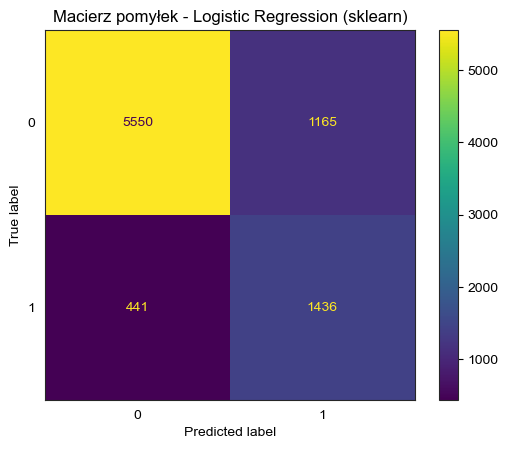

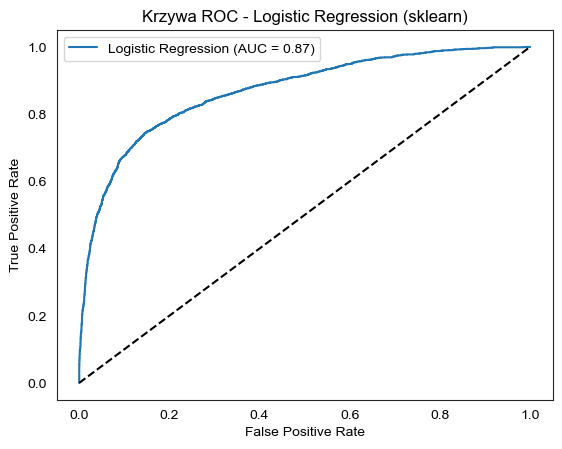

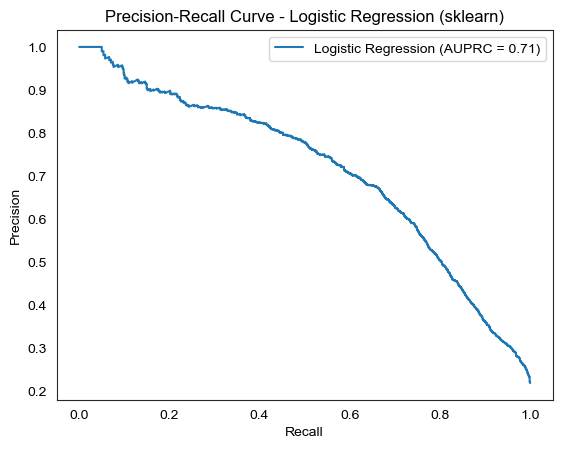

In [28]:
# 13. Trenowanie klasycznej regresji logistycznej (sklearn)
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(max_iter=1000, random_state=42)
logit_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = logit_model.predict(X_test_scaled)
y_proba = logit_model.predict_proba(X_test_scaled)[:, 1]

# Metryki
print("\n=== Wyniki regresji logistycznej (sklearn) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Macierz pomyłek - Logistic Regression (sklearn)')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - Logistic Regression (sklearn)')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
from sklearn.metrics import average_precision_score
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'Logistic Regression (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression (sklearn)')
plt.legend()
plt.show()


In [ ]:
#13.1 Współczynniki regresji oraz ilorazy szans
import numpy as np
import pandas as pd

# Pobranie nazw cech przed skalowaniem
feature_names = X.columns  # Nazwy cech z oryginalnego DataFrame

# Pobranie współczynników regresji
coefficients = logit_model.coef_.flatten()
intercept = logit_model.intercept_[0]

# Przekształcenie współczynników na **szanse (odds ratios)**
odds_ratios = np.exp(coefficients)

# Tworzenie tabeli wyników
params_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient (β)": coefficients,
    "Odds Ratio (e^β)": odds_ratios
})

# Wyświetlenie wyników
print("\n=== Oszacowania parametrów regresji logistycznej ===")
print(f"Intercept (Wyraz wolny): {intercept:.4f}\n")
print(params_table.sort_values(by="Odds Ratio (e^β)", ascending=False))

# Interpretacja wyników
print("\nInterpretacja:")
print("- Wartości 'Coefficient (β)' wskazują kierunek wpływu cechy na wynik (dodatnie wartości zwiększają prawdopodobieństwo klasy 1).")
print("- 'Odds Ratio (e^β)' pokazuje, jak bardzo zmiana jednej jednostki danej zmiennej zwiększa lub zmniejsza szansę na wystąpienie klasy pozytywnej.")
print("- Jeśli 'Odds Ratio' > 1, zmienna zwiększa prawdopodobieństwo klasy 1, jeśli < 1, zmniejsza.")


=== Oszacowania parametrów regresji logistycznej ===
Intercept (Wyraz wolny): -0.7079

                          Feature  Coefficient (β)  Odds Ratio (e^β)
5             loan_percent_income         1.494744          4.458197
19                        grade_D         0.710536          2.035081
20                        grade_E         0.414802          1.514071
4                   loan_int_rate         0.361005          1.434771
16                      home_RENT         0.323497          1.381952
22                        grade_G         0.276943          1.319092
21                        grade_F         0.234505          1.264282
10    loan_intent_HOMEIMPROVEMENT         0.205496          1.228134
8   loan_intent_DEBTCONSOLIDATION         0.155483          1.168222
11            loan_intent_MEDICAL         0.111173          1.117588
18                        grade_C         0.104933          1.110636
7      cb_person_cred_hist_length         0.030082          1.030539
1              


=== Wyniki Random Forest ===
Accuracy: 0.9239
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      6715
           1       0.90      0.73      0.81      1877

    accuracy                           0.92      8592
   macro avg       0.92      0.85      0.88      8592
weighted avg       0.92      0.92      0.92      8592



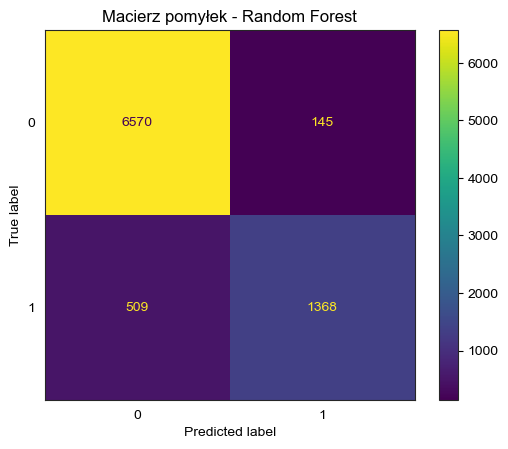

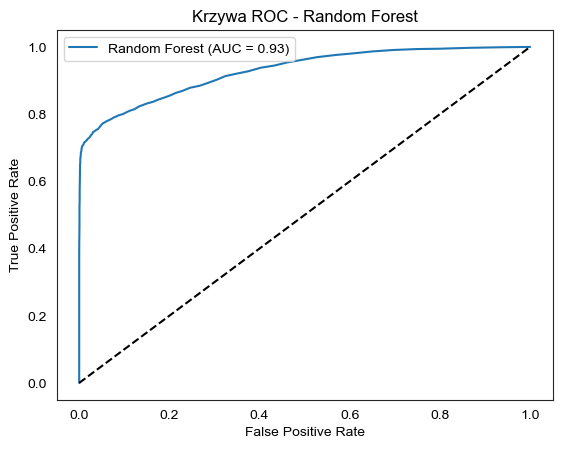

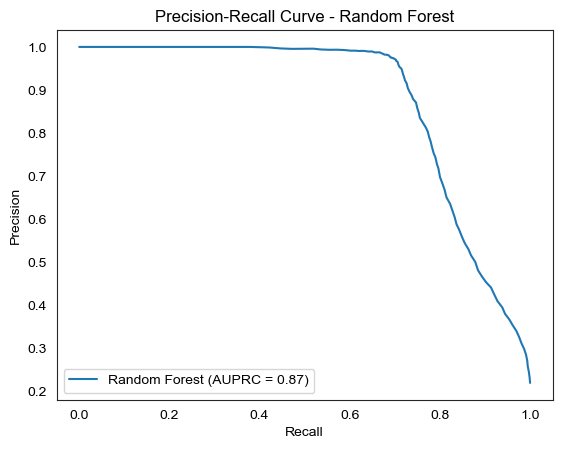

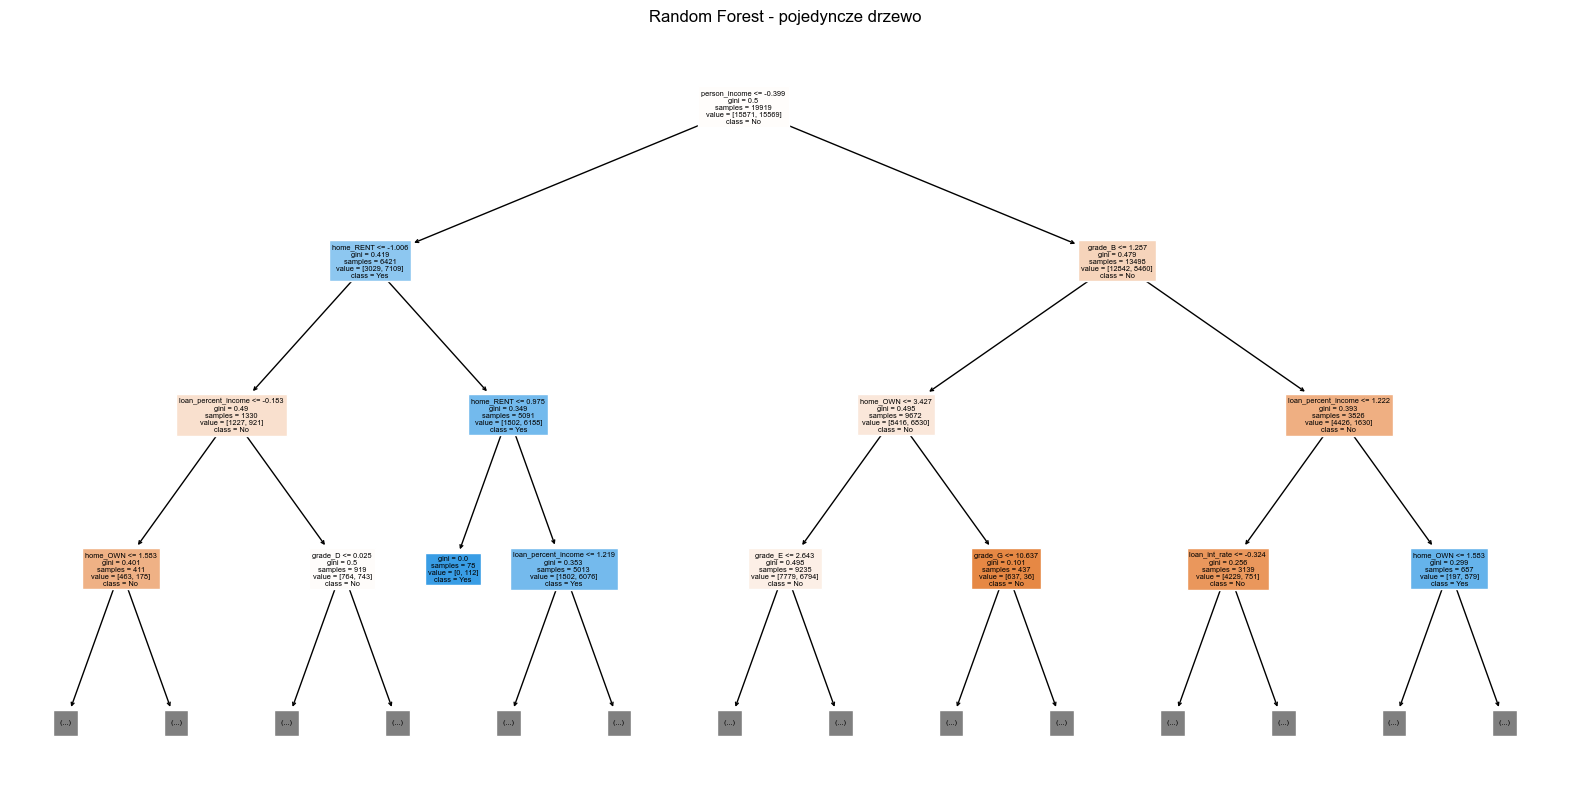

In [ ]:
#14 Random Forest
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metryki
print("\n=== Wyniki Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Macierz pomyłek - Random Forest')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - Random Forest')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'Random Forest (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.legend()
plt.show()

# Wizualizacja drzewa i zapis do pliku JPG
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(rf_model.estimators_[0], filled=True, max_depth=3, feature_names=X.columns, class_names=['No', 'Yes'], ax=ax)
plt.title("Random Forest - pojedyncze drzewo")

# Zapis do pliku
plt.savefig("random_forest_tree.jpg", dpi=300, bbox_inches="tight")
plt.show()


=== Wyniki Decision Tree ===
Accuracy: 0.8786
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      6715
           1       0.72      0.72      0.72      1877

    accuracy                           0.88      8592
   macro avg       0.82      0.82      0.82      8592
weighted avg       0.88      0.88      0.88      8592



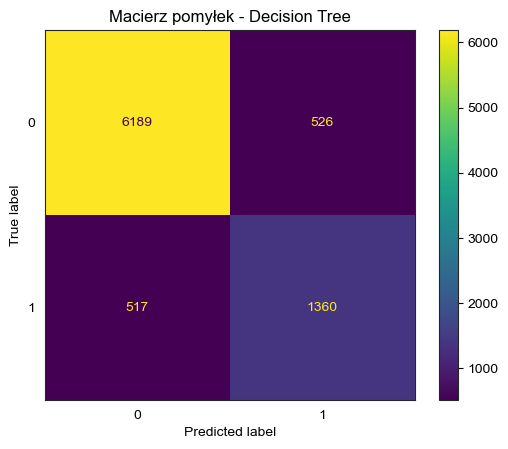

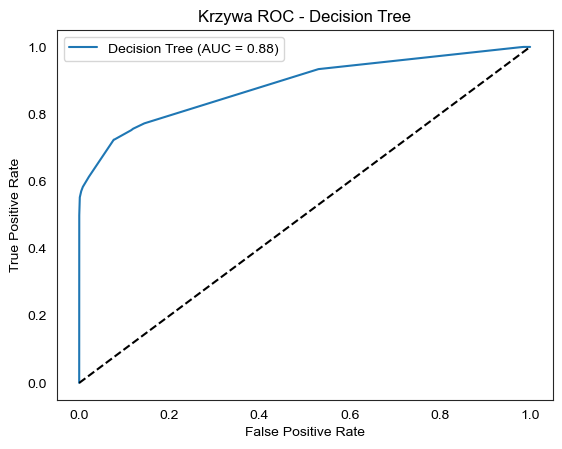

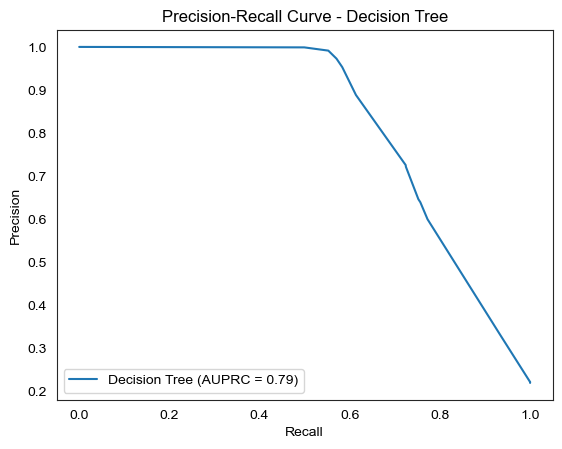

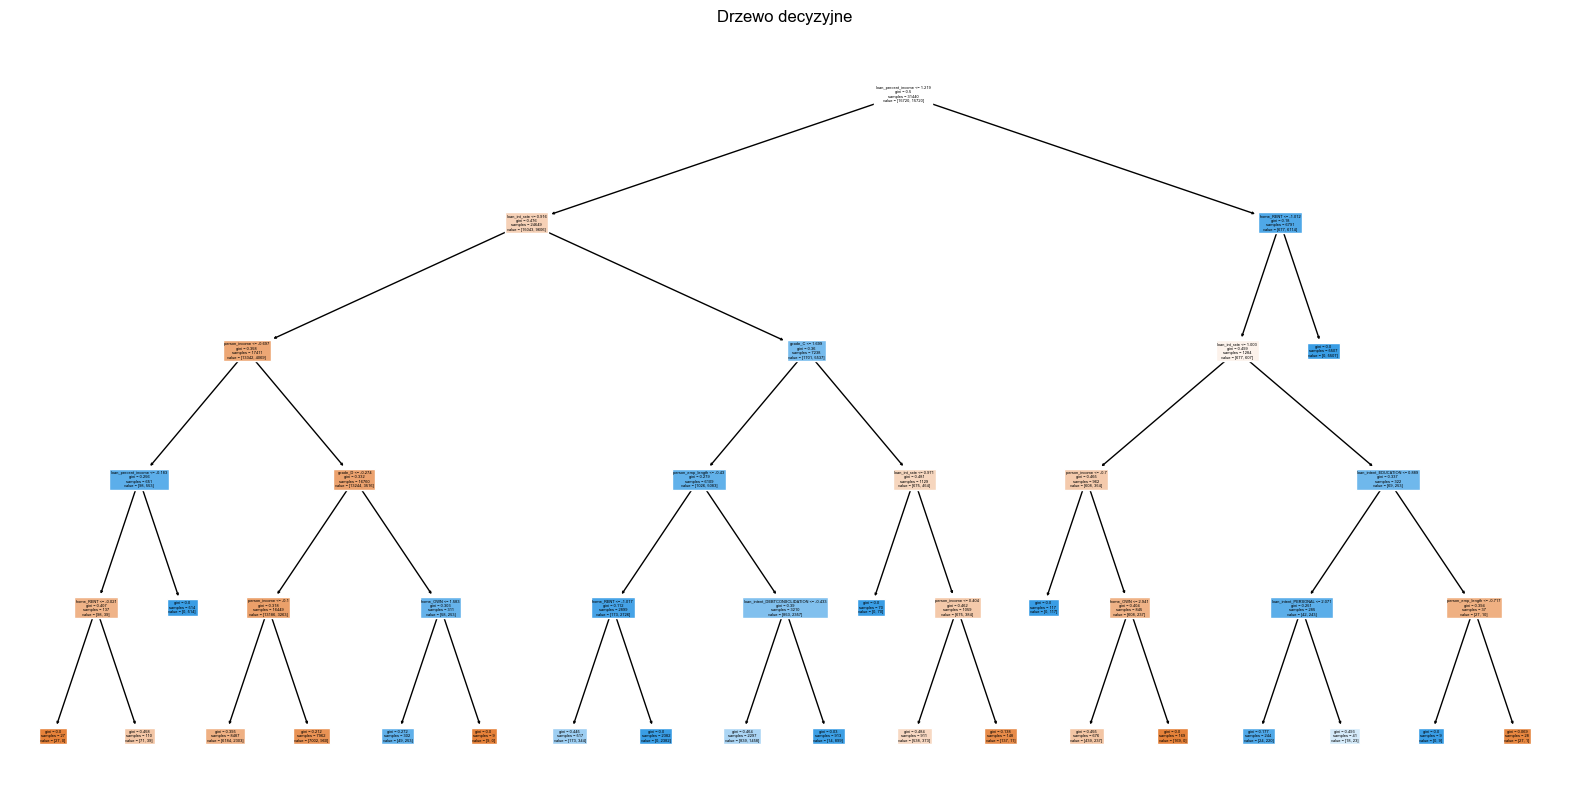

In [ ]:
#15 Decision Tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = dt_model.predict(X_test_scaled)
y_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

# Metryki
print("\n=== Wyniki Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Macierz pomyłek - Decision Tree')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - Decision Tree')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'Decision Tree (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Decision Tree')
plt.legend()
plt.show()

# Wizualizacja drzewa i zapis do pliku JPG
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, ax=ax)
plt.title("Drzewo decyzyjne")

# Zapis do pliku
plt.savefig("decision_tree.jpg", dpi=300, bbox_inches="tight")
plt.show()

c:\Users\kamil\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:11:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Wyniki XGBoost ===
Accuracy: 0.9306
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      6715
           1       0.94      0.73      0.82      1877

    accuracy                           0.93      8592
   macro avg       0.93      0.86      0.89      8592
weighted avg       0.93      0.93      0.93      8592



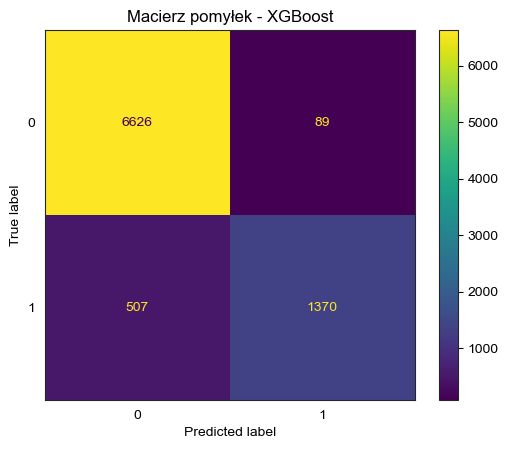

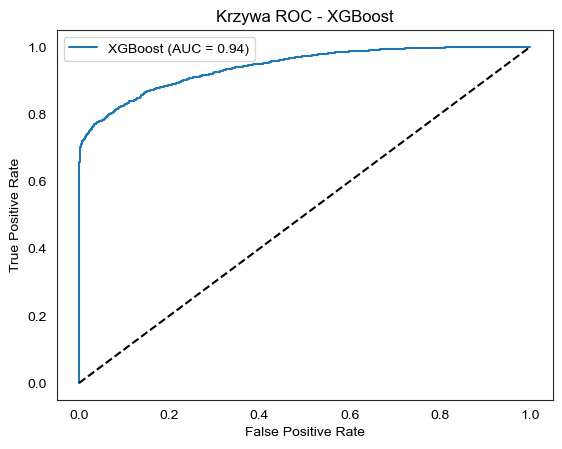

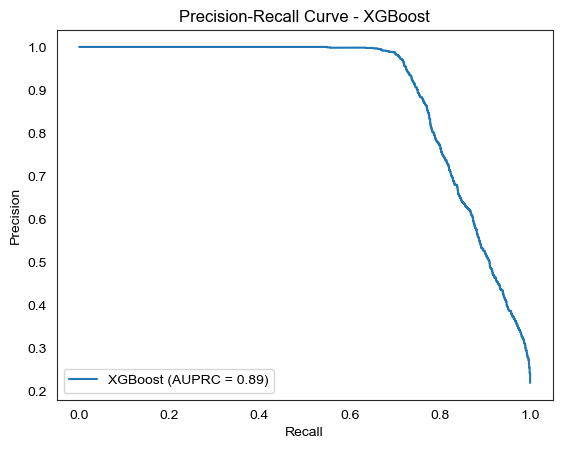

 96%|=================== | 8214/8592 [00:16<00:00]       

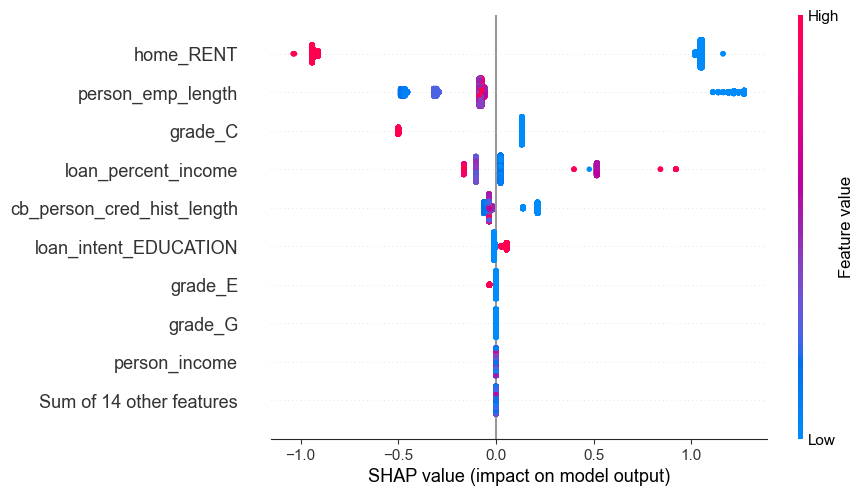

<Figure size 1000x600 with 0 Axes>

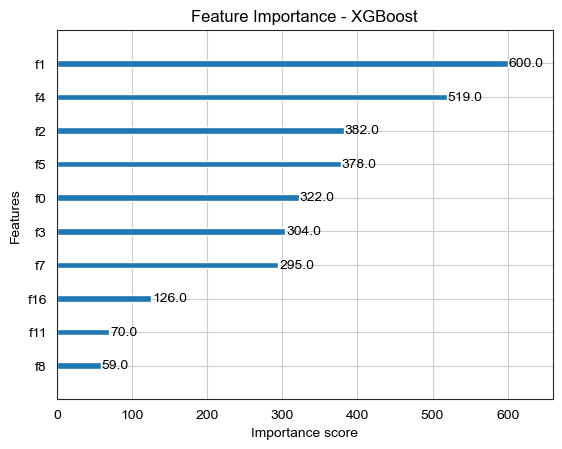

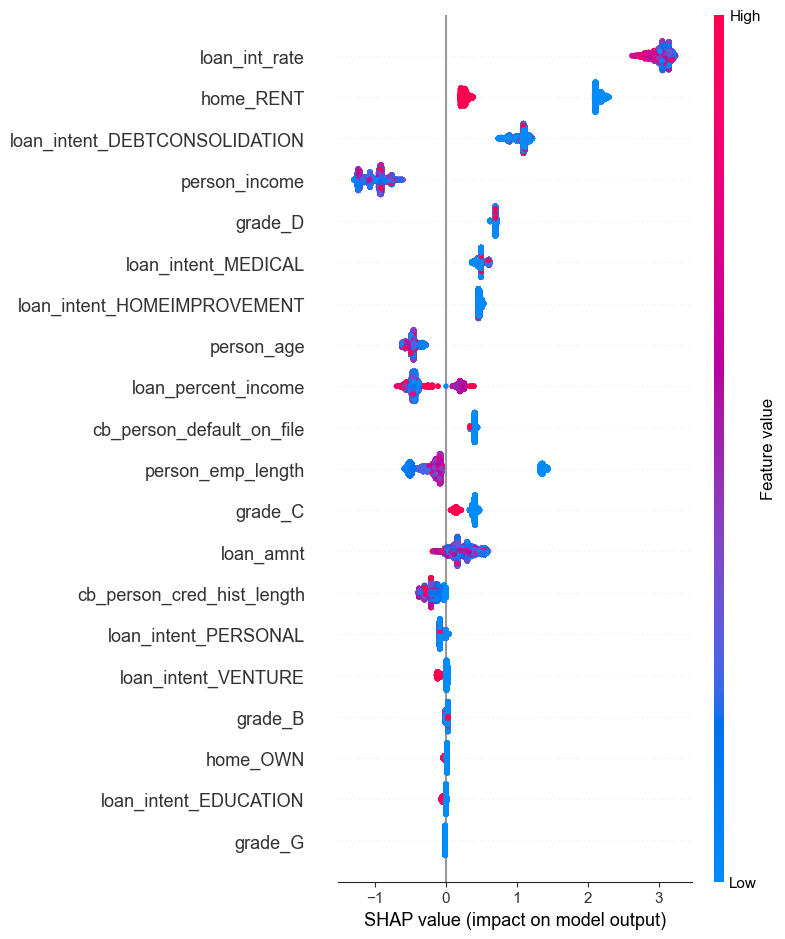

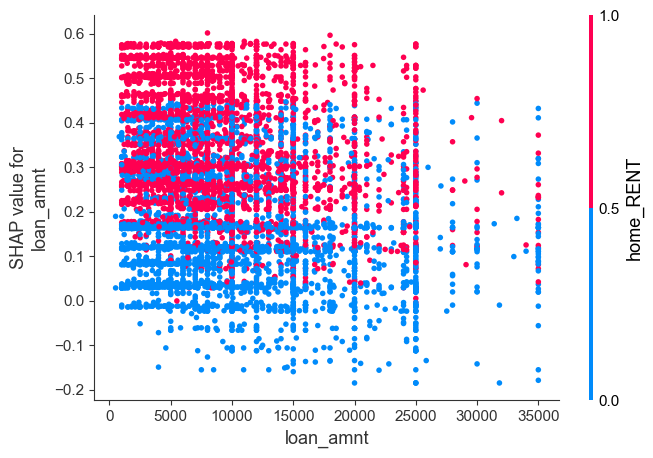

In [ ]:
#16 XGBoost - Gradient Boosting z drzewami + Wizualizacje
from xgboost import XGBClassifier, plot_importance
import shap
import matplotlib.pyplot as plt

# Trenowanie modelu
xgb_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Metryki
print("\n=== Wyniki XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Macierz pomyłek - XGBoost')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - XGBoost')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'XGBoost (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend()
plt.show()

# SHAP Analiza (Beeswarm Plot)
explainer = shap.Explainer(xgb_model, X_train.astype(float))
shap_values = explainer(X_test.astype(float))
shap.plots.beeswarm(shap_values)

# Feature Importance - Ważność cech
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, importance_type='weight', max_num_features=10)
plt.title("Feature Importance - XGBoost")
plt.show()

# SHAP Summary Plot - Globalny wpływ zmiennych
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.to_numpy())  # Konwersja do numpy array, aby uniknąć błędów
shap.summary_plot(shap_values, X_test)

# SHAP Dependence Plot - Wpływ konkretnej zmiennej na predykcję
shap.dependence_plot("loan_amnt", shap_values, X_test)

In [ ]:
#17 CatBoost - Gradient Boosting z drzewami + Wizualizacje
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt

# Trenowanie modelu
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = cat_model.predict(X_test_scaled)
y_proba = cat_model.predict_proba(X_test_scaled)[:, 1]

# Metryki
print("\n=== Wyniki CatBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Macierz pomyłek - CatBoost')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - CatBoost')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'CatBoost (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - CatBoost')
plt.legend()
plt.show()

# SHAP Analiza (Beeswarm Plot)
explainer = shap.Explainer(cat_model, X_train.astype(float))
shap_values = explainer(X_test.astype(float))
shap.plots.beeswarm(shap_values)

# Feature Importance - Ważność cech
feature_importances = cat_model.get_feature_importance()
sorted_idx = feature_importances.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx], color='#8A2BE2')
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.title("Feature Importance - CatBoost")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# SHAP Summary Plot - Globalny wpływ zmiennych
explainer = shap.Explainer(cat_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

[LightGBM] [Info] Number of positive: 15720, number of negative: 15720
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2342
[LightGBM] [Info] Number of data points in the train set: 31440, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== Wyniki LightGBM ===
Accuracy: 0.2185


c:\Users\kamil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\kamil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\kamil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6715
           1       0.22      1.00      0.36      1877

    accuracy                           0.22      8592
   macro avg       0.11      0.50      0.18      8592
weighted avg       0.05      0.22      0.08      8592



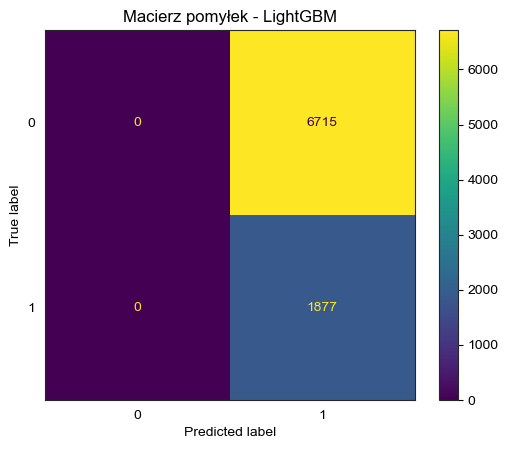

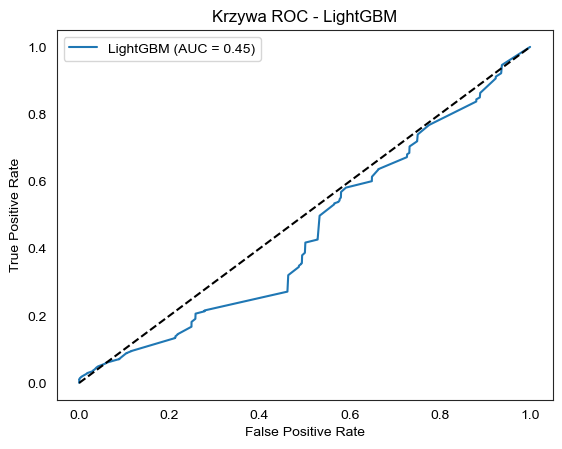

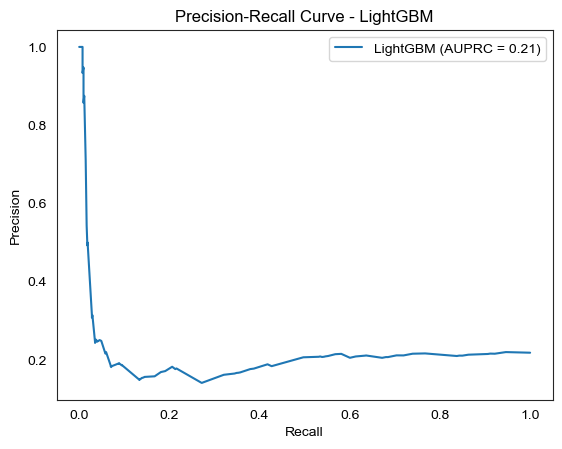

 99%|===================| 8511/8592 [00:19<00:00]        

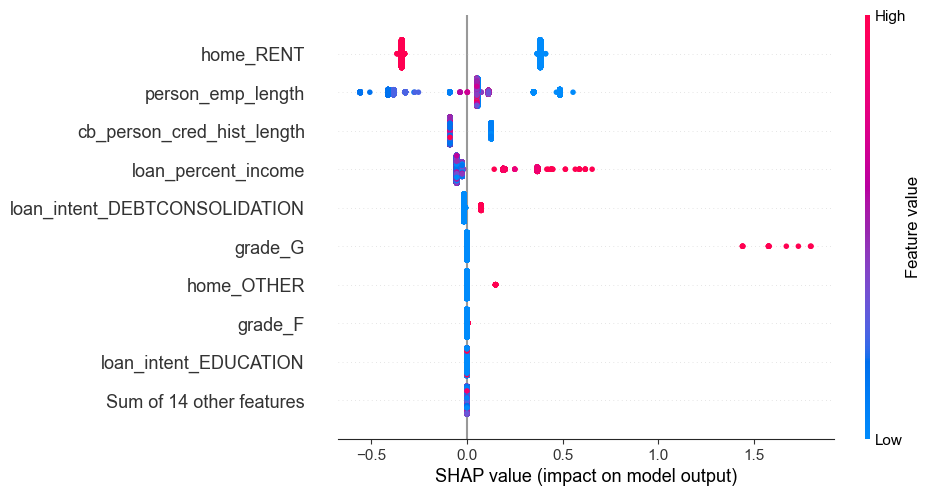

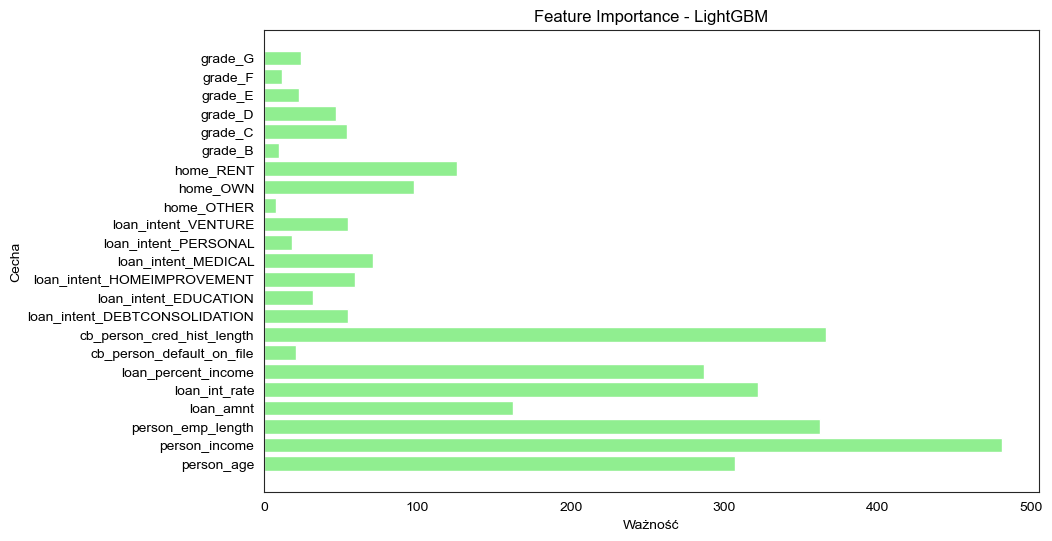

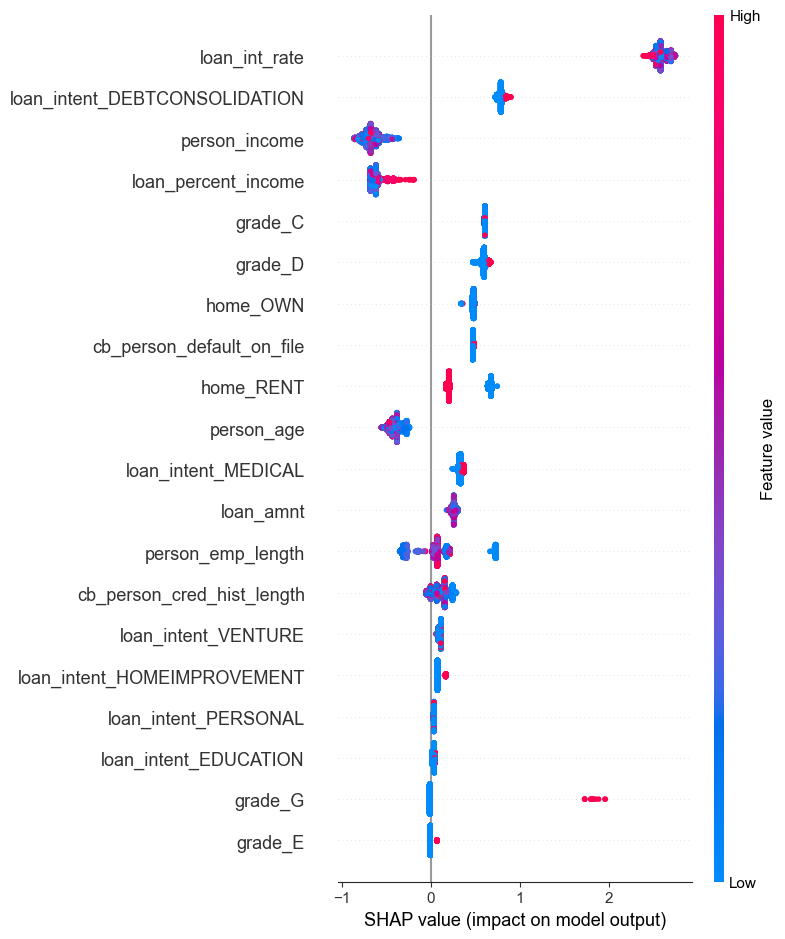

In [ ]:
#18 LightGBM - Gradient Boosting z drzewami + Wizualizacje
from lightgbm import LGBMClassifier
import shap
import matplotlib.pyplot as plt

# Trenowanie modelu
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = lgbm_model.predict(X_test)
y_proba = lgbm_model.predict_proba(X_test)[:, 1]

# Metryki
print("\n=== Wyniki LightGBM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Macierz pomyłek - LightGBM')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - LightGBM')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'LightGBM (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - LightGBM')
plt.legend()
plt.show()

# SHAP Analiza (Beeswarm Plot)
explainer = shap.Explainer(lgbm_model, X_train.astype(float))
shap_values = explainer(X_test.astype(float))
shap.plots.beeswarm(shap_values)

# Feature Importance - Ważność cech
feature_importances = lgbm_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(X.columns, feature_importances, color='lightgreen')
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.title("Feature Importance - LightGBM")
plt.show()

# SHAP Summary Plot - Globalny wpływ zmiennych
explainer = shap.Explainer(lgbm_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


=== Wyniki SVM ===
Accuracy: 0.8828
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      6715
           1       0.74      0.72      0.73      1877

    accuracy                           0.88      8592
   macro avg       0.83      0.83      0.83      8592
weighted avg       0.88      0.88      0.88      8592



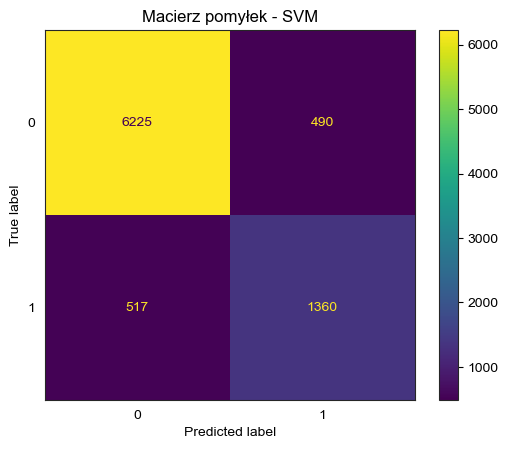

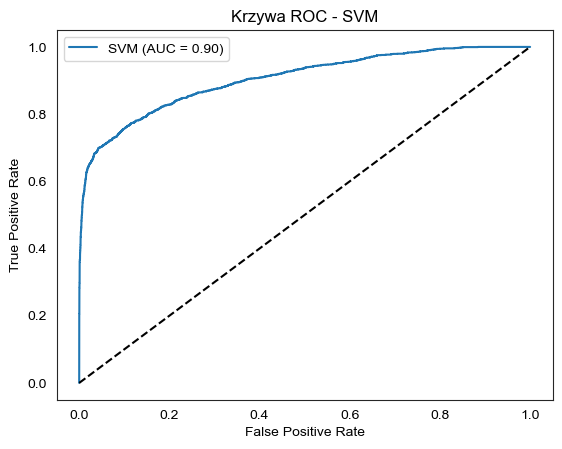

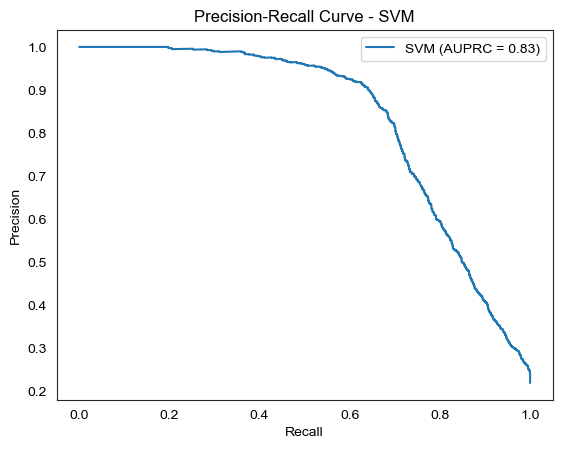

In [ ]:
#19 SVM - Support vector machine (klasyczny model maszyn wektorowych) + Wizualizacje
from sklearn.svm import SVC
import shap
import matplotlib.pyplot as plt

# Trenowanie modelu
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# Metryki
print("\n=== Wyniki SVM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Macierz pomyłek - SVM')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - SVM')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'SVM (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM')
plt.legend()
plt.show()


Early stopping occurred at epoch 45 with best_epoch = 35 and best_val_logloss = 0.27735


c:\Users\kamil\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
c:\Users\kamil\anaconda3\Lib\site-packages\torch\utils\data\_utils\collate.py:285: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  return collate([torch.as_tensor(b) for b in batch], collate_fn_map=collate_fn_map)



=== Wyniki modelu TabNet ===
Accuracy: 0.9095
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      6715
           1       0.87      0.68      0.77      1877

    accuracy                           0.91      8592
   macro avg       0.90      0.83      0.86      8592
weighted avg       0.91      0.91      0.91      8592



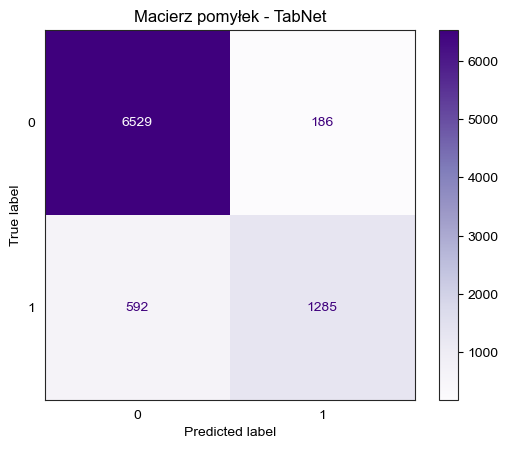

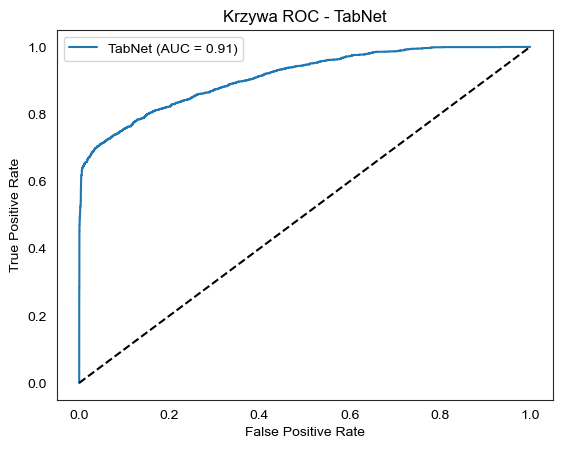

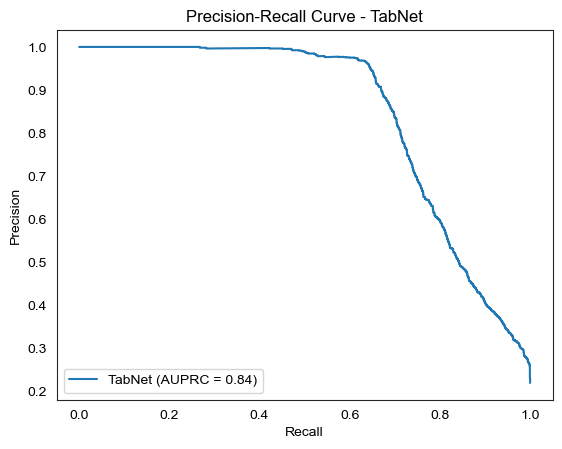

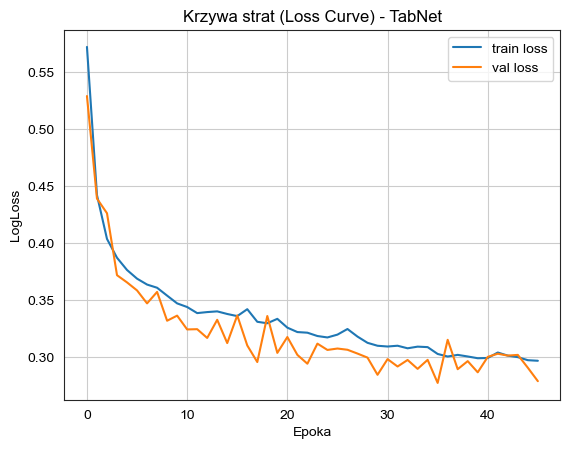

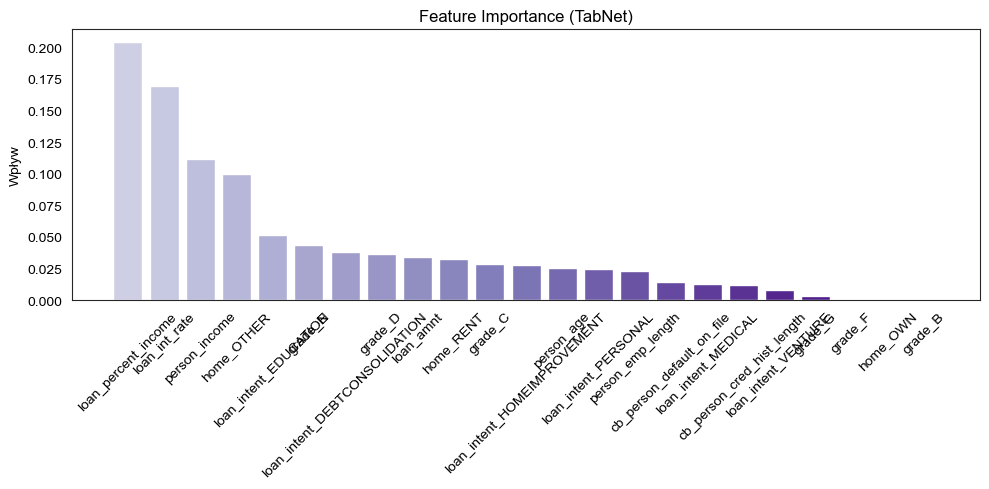

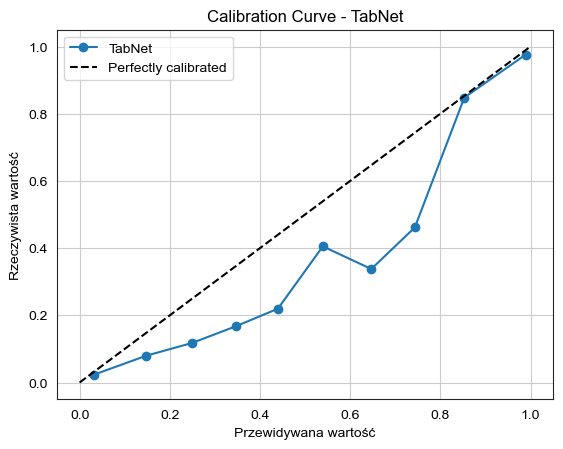

In [30]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.calibration import calibration_curve

# Trening modelu TabNet
tabnet_model = TabNetClassifier(seed=42, verbose=0)
tabnet_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    eval_name=["val"],
    eval_metric=["auc", "logloss"],
    max_epochs=100,
    patience=10
)

# Predykcje
y_proba = tabnet_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba > 0.5).astype(int)

# Metryki
print("\n=== Wyniki modelu TabNet ===")
print(f"Accuracy: {(y_pred == y_test).mean():.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Macierz pomyłek - TabNet')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'TabNet (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - TabNet')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'TabNet (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - TabNet')
plt.legend()
plt.show()

# Krzywa strat (Loss Curve)
plt.plot(tabnet_model.history['loss'], label='train loss')
plt.plot(tabnet_model.history['val_logloss'], label='val loss')
plt.title("Krzywa strat (Loss Curve) - TabNet")
plt.xlabel("Epoka")
plt.ylabel("LogLoss")
plt.legend()
plt.grid(True)
plt.show()

# Wpływ cech wg TabNet
importances = tabnet_model.feature_importances_
features = X.columns if hasattr(X, 'columns') else [f'x{i}' for i in range(len(importances))]

sorted_importances = pd.Series(importances, index=features).sort_values(ascending=False)
colors = plt.cm.Purples(np.linspace(0.3, 1, len(sorted_importances)))  # fioletowy gradient

plt.figure(figsize=(10, 5))
plt.bar(sorted_importances.index, sorted_importances.values, color=colors)
plt.title("Feature Importance (TabNet)")
plt.ylabel("Wpływ")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='TabNet')
plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
plt.xlabel('Przewidywana wartość')
plt.ylabel('Rzeczywista wartość')
plt.title('Calibration Curve - TabNet')
plt.legend()
plt.grid(True)
plt.show()


In [31]:
'''
# Strojenie hiperparametrów w MLP
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {
    'hidden_layer_sizes': [(64,), (128,), (64, 64), (128, 64)],
    'alpha': uniform(1e-5, 0.01),
    'activation': ['relu', 'tanh'],
    'learning_rate_init': uniform(0.0001, 0.01),
}

search = RandomizedSearchCV(
    MLPClassifier(max_iter=300, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=42
)
search.fit(X_train_resampled, y_train_resampled)

print("Najlepsze parametry:", search.best_params_)

# WYNIK: Najlepsze parametry: {'activation': 'tanh', 'alpha': 0.0004766566321361543, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.003763618432936917}
'''

'\n# Strojenie hiperparametrów w MLP\nfrom sklearn.neural_network import MLPClassifier\nfrom sklearn.model_selection import RandomizedSearchCV\nfrom scipy.stats import uniform\n\nparam_dist = {\n    \'hidden_layer_sizes\': [(64,), (128,), (64, 64), (128, 64)],\n    \'alpha\': uniform(1e-5, 0.01),\n    \'activation\': [\'relu\', \'tanh\'],\n    \'learning_rate_init\': uniform(0.0001, 0.01),\n}\n\nsearch = RandomizedSearchCV(\n    MLPClassifier(max_iter=300, random_state=42),\n    param_distributions=param_dist,\n    n_iter=20,\n    scoring=\'roc_auc\',\n    cv=5,\n    n_jobs=-1,\n    random_state=42\n)\nsearch.fit(X_train_resampled, y_train_resampled)\n\nprint("Najlepsze parametry:", search.best_params_)\n\n# WYNIK: Najlepsze parametry: {\'activation\': \'tanh\', \'alpha\': 0.0004766566321361543, \'hidden_layer_sizes\': (128, 64), \'learning_rate_init\': 0.003763618432936917}\n'


=== Wyniki Sieci Neuronowej (MLP) ===
Accuracy: 0.8605
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      6715
           1       0.67      0.71      0.69      1877

    accuracy                           0.86      8592
   macro avg       0.79      0.81      0.80      8592
weighted avg       0.86      0.86      0.86      8592



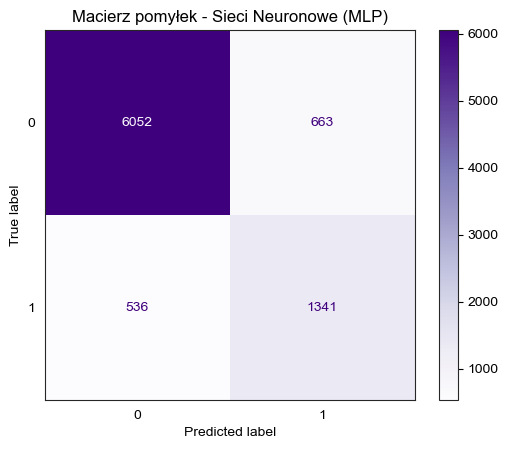

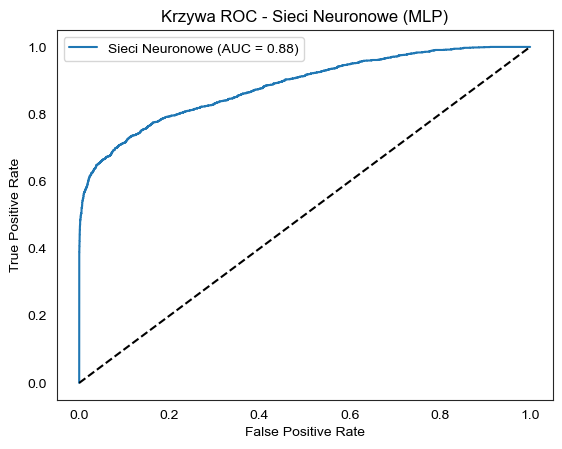

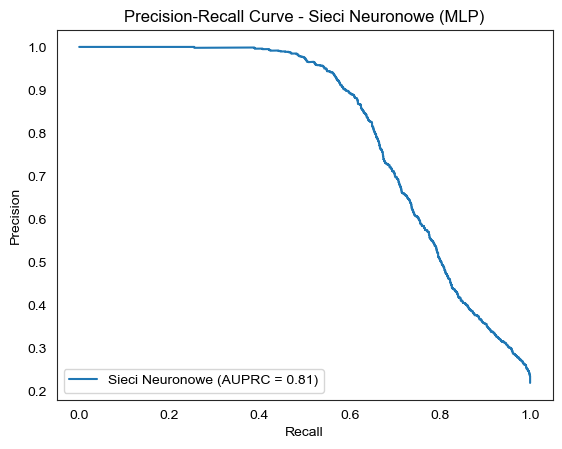

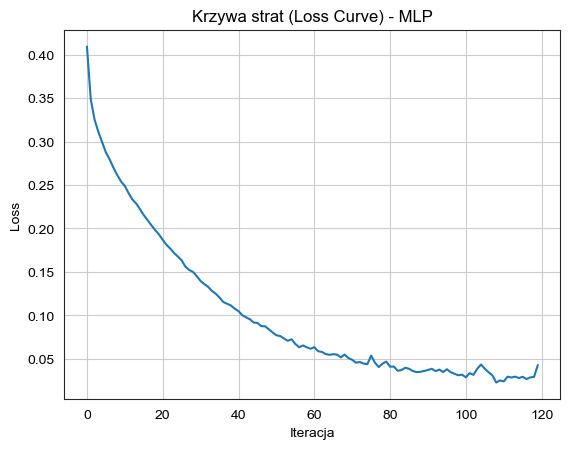

C:\Users\kamil\AppData\Local\Temp\ipykernel_20364\3551981410.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


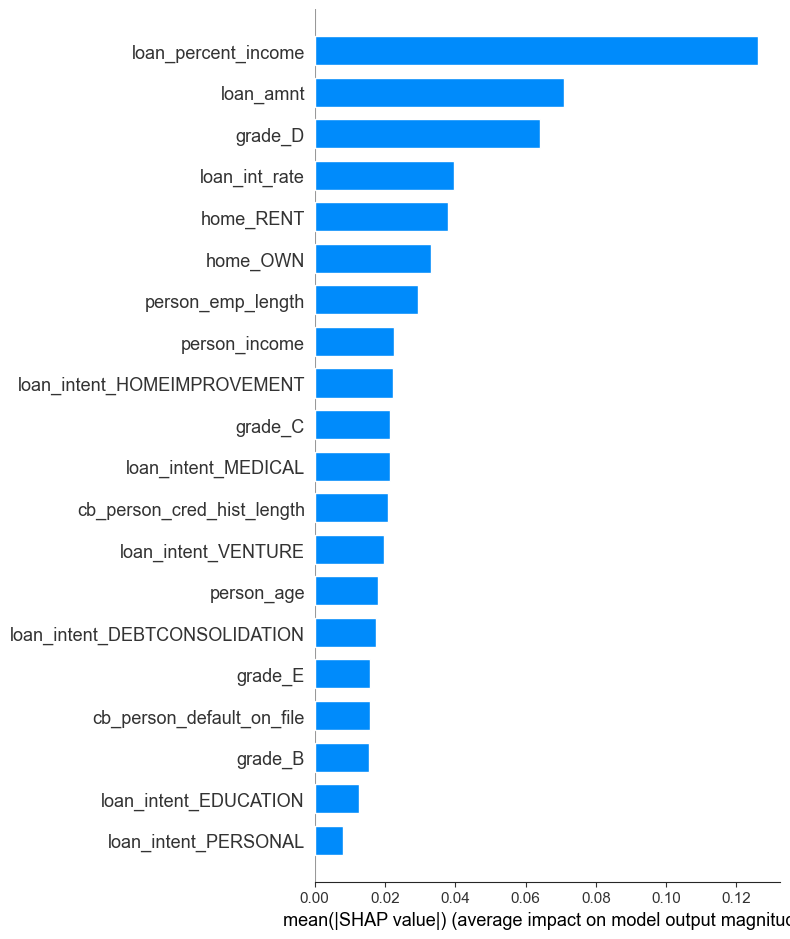

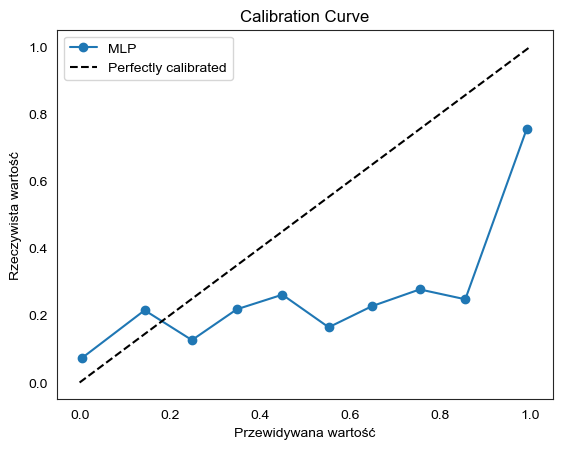

In [33]:
#20 Sieci Neuronowe - MLP + Wizualizacje
from sklearn.neural_network import MLPClassifier
import shap
import matplotlib.pyplot as plt

# Trenowanie modelu
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='tanh',
    alpha=0.0004766566321361543,
    learning_rate_init=0.003763618432936917,
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_resampled, y_train_resampled)

# Predykcje
y_pred = mlp_model.predict(X_test_scaled)
y_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Metryki
print("\n=== Wyniki Sieci Neuronowej (MLP) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Purples")
plt.title('Macierz pomyłek - Sieci Neuronowe (MLP)')
plt.show()

# Krzywa ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
plt.plot(fpr, tpr, label=f'Sieci Neuronowe (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC - Sieci Neuronowe (MLP)')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
plt.plot(recall, precision, label=f'Sieci Neuronowe (AUPRC = {auprc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Sieci Neuronowe (MLP)')
plt.legend()
plt.show()

# Analiza strat (Loss Curve)
plt.plot(mlp_model.loss_curve_)
plt.title("Krzywa strat (Loss Curve) - MLP")
plt.xlabel("Iteracja")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Analiza wpływu cech (shap)

explainer = shap.Explainer(mlp_model.predict, X_test_scaled[:100])
shap_values = explainer(X_test_scaled[:100])

shap.summary_plot(
    shap_values,
    X_test_scaled[:100],
    feature_names=X.columns,
    plot_type="bar"
)

# Calibration Curve
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='MLP')
plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
plt.xlabel('Przewidywana wartość')
plt.ylabel('Rzeczywista wartość')
plt.title('Calibration Curve')
plt.legend()
plt.show()


In [ ]:
##################################################################################################
# ZBIORCZA ANALIZA (TABELKI I WYKRESY)                                                           #
# bloki #21 oraz #22 są jedynie pomocnicze, aby później zebrać wyniki w #23, #24, #25            #
##################################################################################################

In [ ]:
#21 Funkcja ewaluacji
results = {}
metrics_table = {}

def full_evaluation(model, name, scaled=True, shap_analysis=False):
    model.fit(X_train_scaled if scaled else X_train, y_train)
    X_eval = X_test_scaled if scaled else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print("Parametry:", model.get_params())
    print("Dokładność:", acc)
    print("Precyzja:", prec)
    print("Czułość:", rec)
    print("F1:", f1)
    print("AUC:", auc)
    print("Macierz pomyłek:\n", confusion_matrix(y_test, y_pred))

    metrics_table[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}
    results[name] = {'model': model, 'proba': y_proba}

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(recall, precision, label=f"{name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.grid()
    plt.legend()
    plt.show()

    # Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
    disp.plot(cmap=plt.cm.Blues)
    disp.plot(cmap="Purples")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # SHAP
    if shap_analysis:
        explainer = shap.Explainer(model, X_train.astype(float))
        shap_values = explainer(X_test.astype(float))
        shap.plots.beeswarm(shap_values)


=== LogisticRegression ===
Parametry: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Dokładność: 0.8623137802607076
Precyzja: 0.7578008915304606
Czułość: 0.5434203516249334
F1: 0.6329506670803599
AUC: 0.8667911239676438
Macierz pomyłek:
 [[6389  326]
 [ 857 1020]]


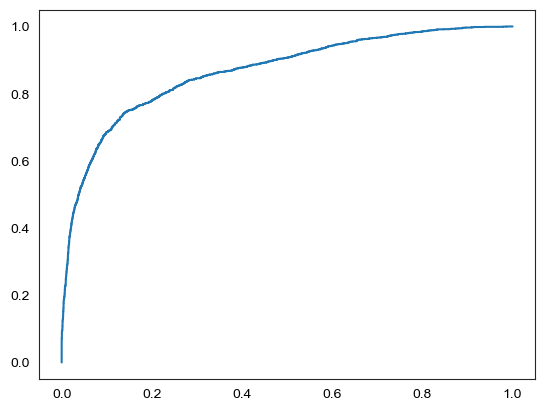

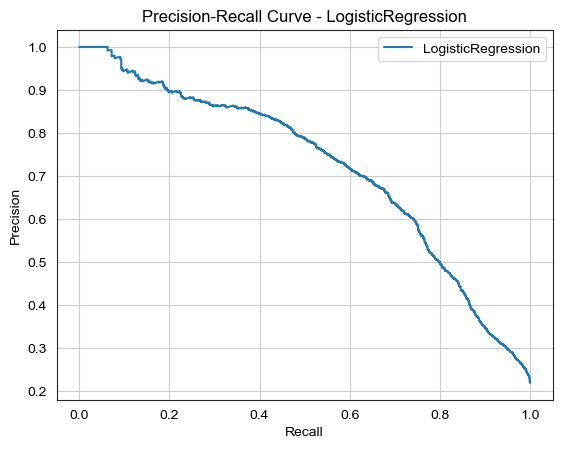

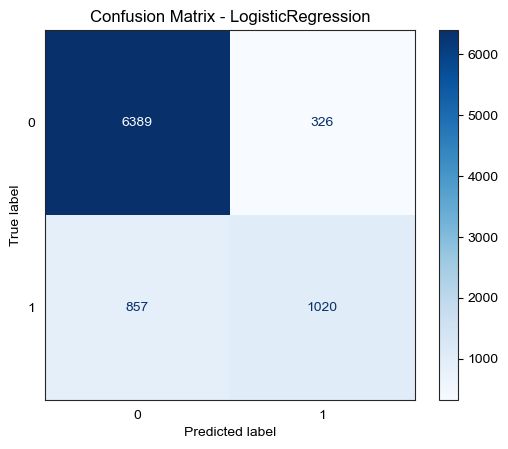


=== RandomForest ===
Parametry: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Dokładność: 0.929352886405959
Precyzja: 0.9601449275362319
Czułość: 0.7059136920618008
F1: 0.8136321768498619
AUC: 0.9262058123357918
Macierz pomyłek:
 [[6660   55]
 [ 552 1325]]


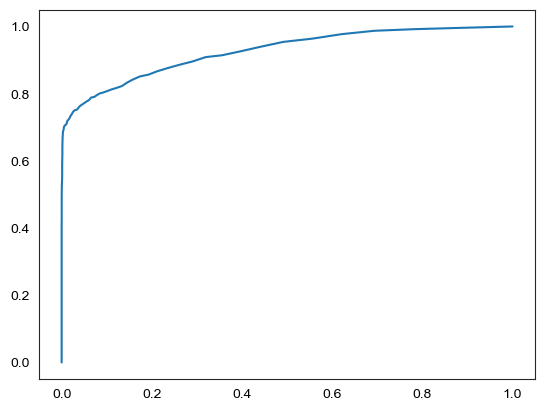

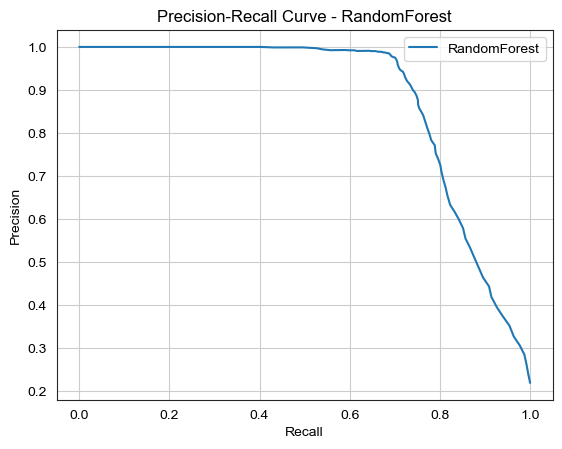

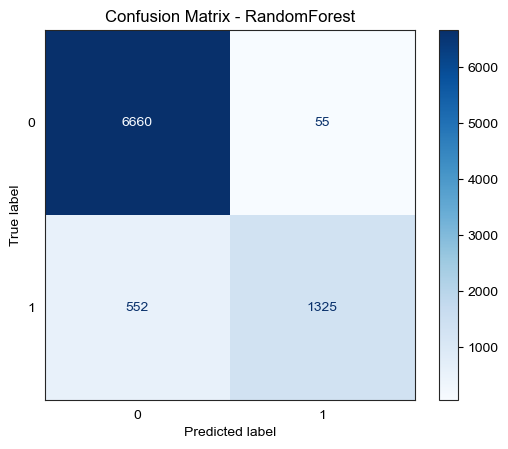

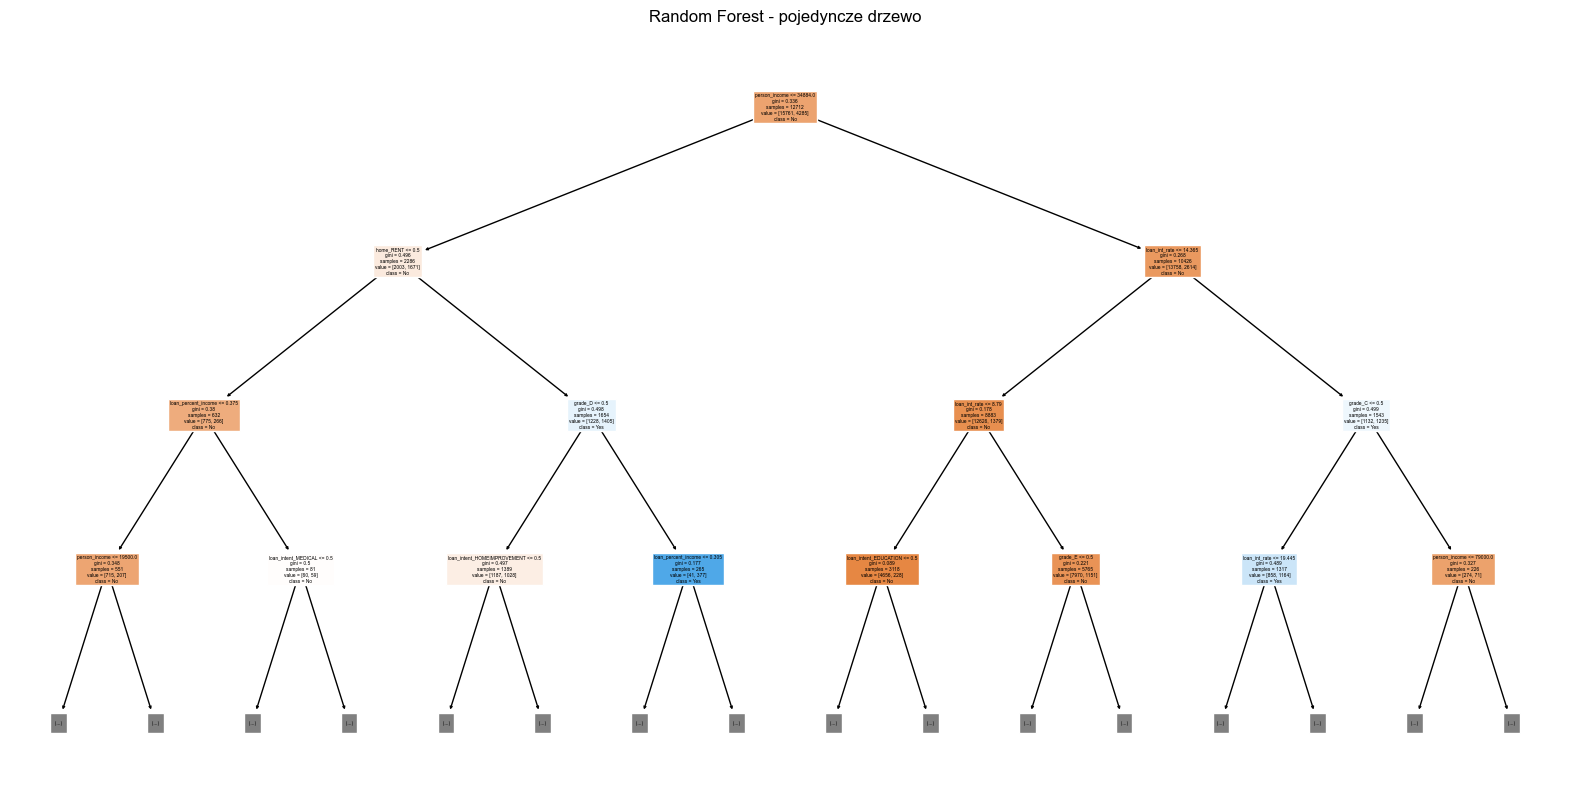


=== DecisionTree ===
Parametry: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': 42, 'splitter': 'best'}
Dokładność: 0.9089851024208566
Precyzja: 0.89587852494577
Czułość: 0.6600958977091103
F1: 0.7601226993865029
AUC: 0.8715412619192793
Macierz pomyłek:
 [[6571  144]
 [ 638 1239]]


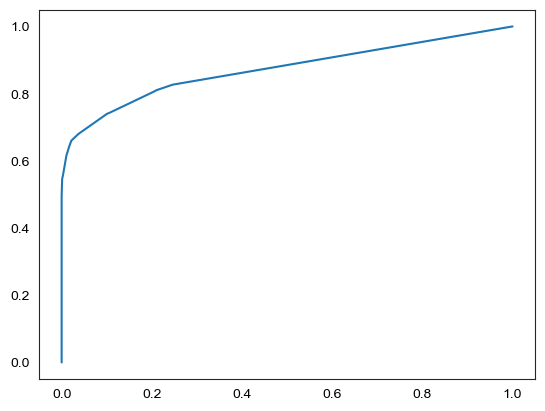

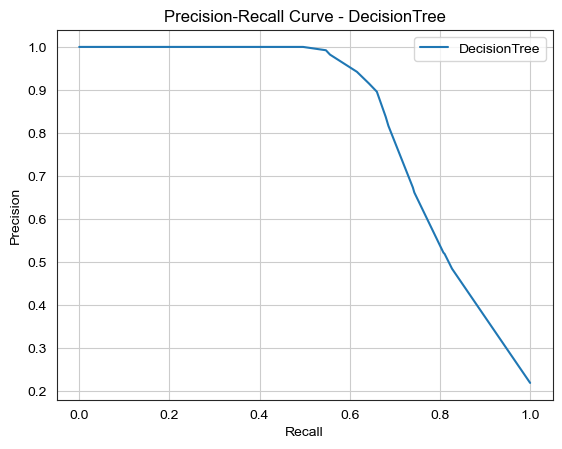

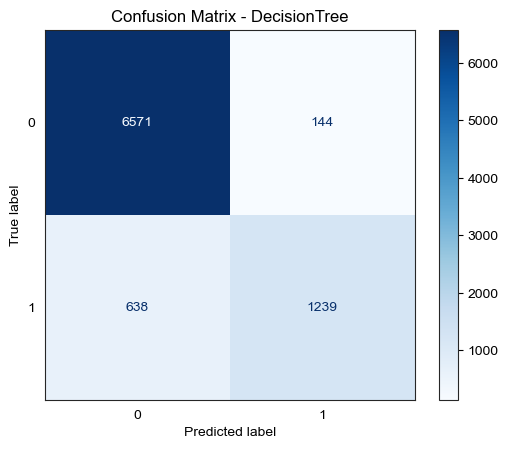

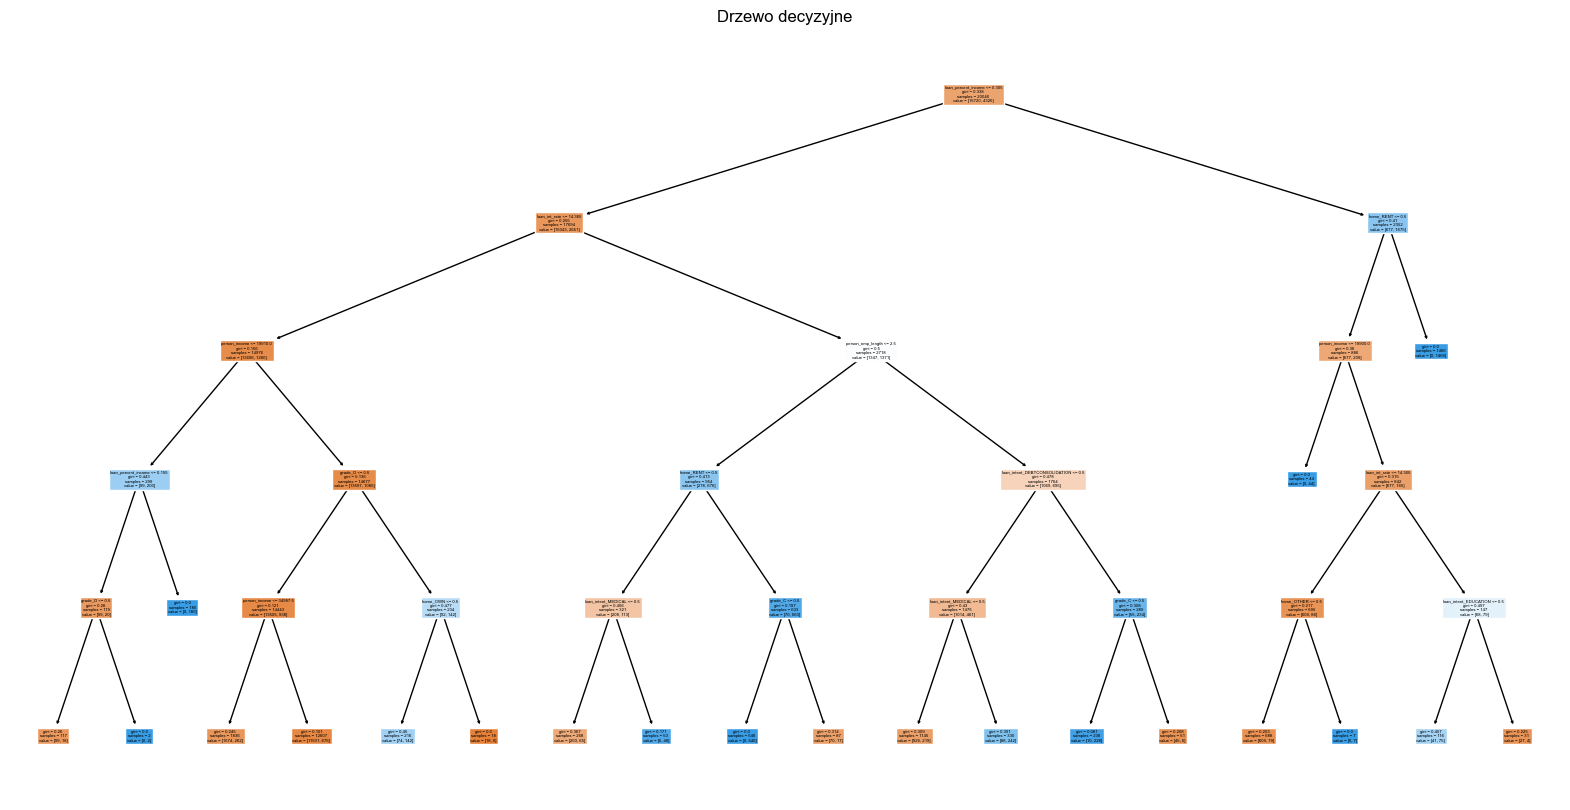


=== CatBoost ===
Parametry: {'verbose': 0, 'random_state': 42}
Dokładność: 0.936219739292365
Precyzja: 0.9722814498933902
Czułość: 0.728822589238146
F1: 0.8331303288672351
AUC: 0.9456290059032589
Macierz pomyłek:
 [[6676   39]
 [ 509 1368]]


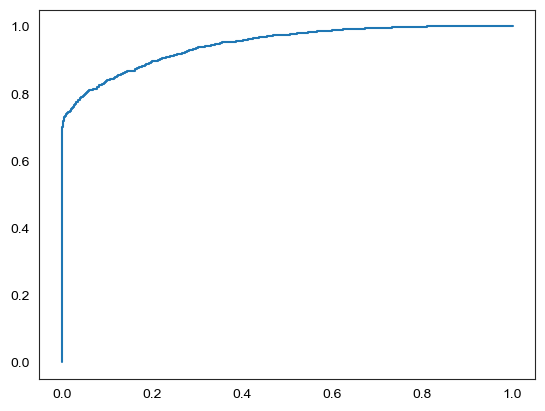

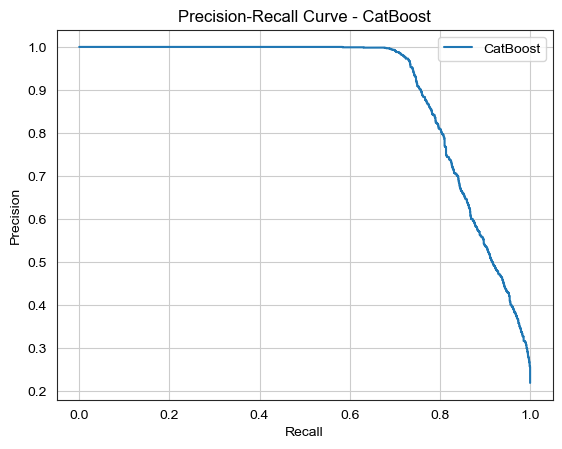

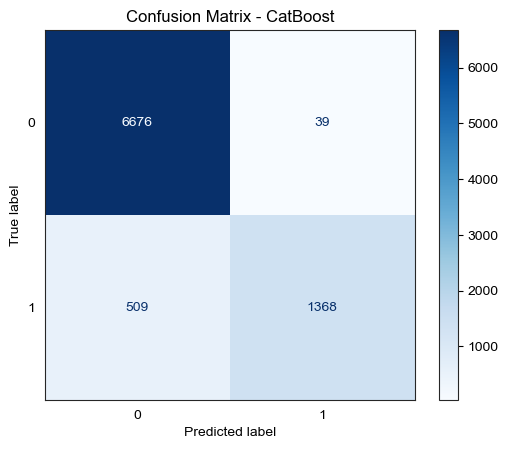

100%|===================| 8585/8592 [09:42<00:00]        

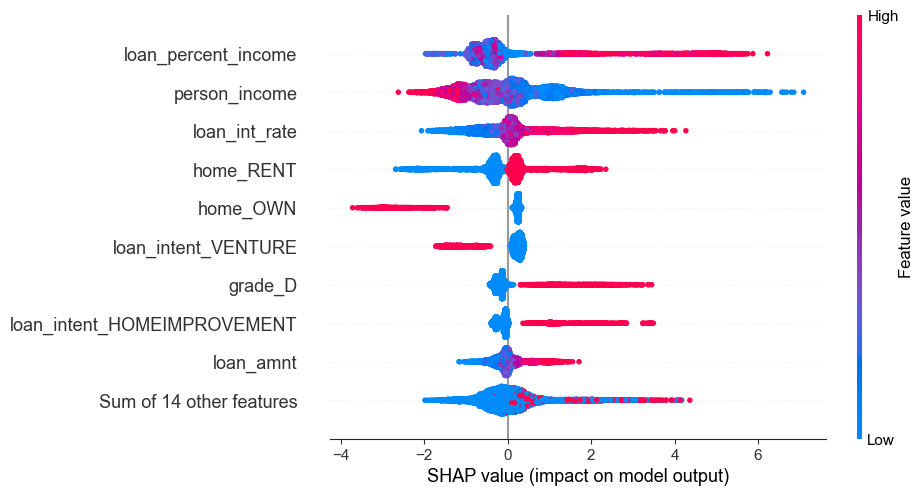


=== SVM ===
Parametry: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Dokładność: 0.9078212290502793
Precyzja: 0.9308975377283558
Czułość: 0.6244006393180608
F1: 0.7474489795918366
AUC: 0.8942775559135532
Macierz pomyłek:
 [[6628   87]
 [ 705 1172]]


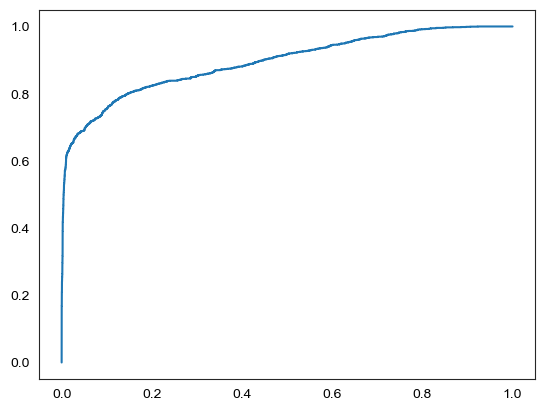

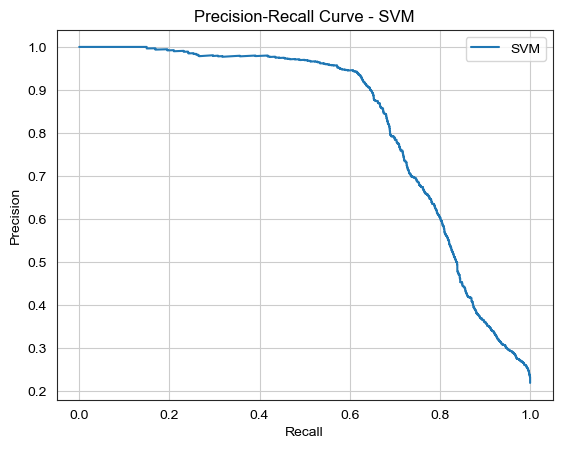

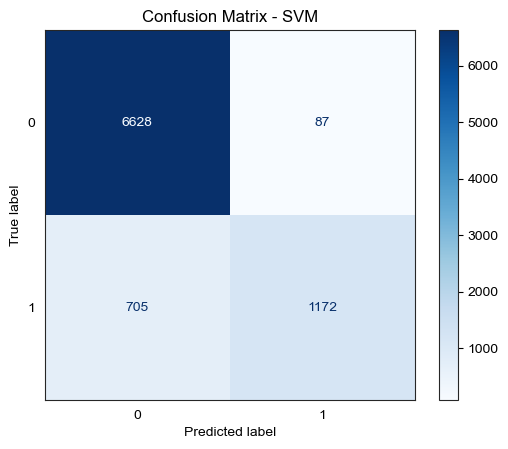


=== NeuralNet ===
Parametry: {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 300, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
Dokładność: 0.910963687150838
Precyzja: 0.8615084525357607
Czułość: 0.7059136920618008
F1: 0.7759882869692531
AUC: 0.9128476510138999
Macierz pomyłek:
 [[6502  213]
 [ 552 1325]]


c:\Users\kamil\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


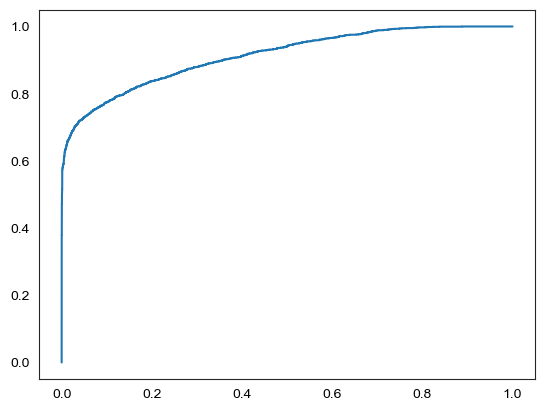

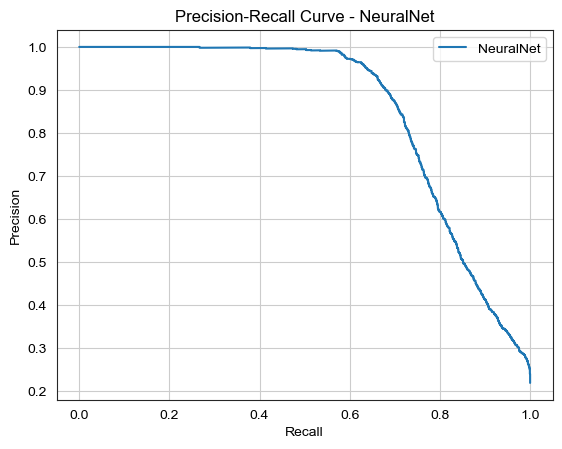

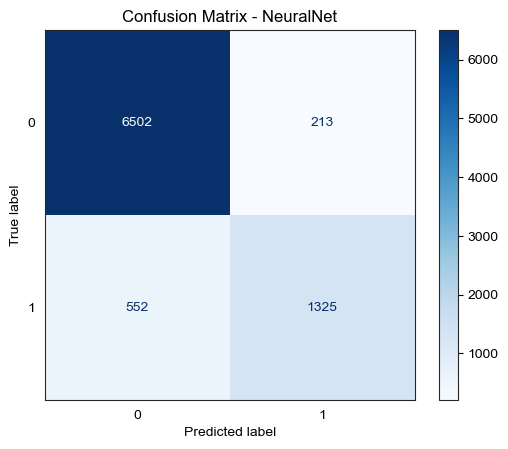

In [ ]:
#22 MODELE
full_evaluation(LogisticRegression(max_iter=1000), "LogisticRegression", scaled=True)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
full_evaluation(rf_model, "RandomForest", scaled=False)

plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0], filled=True, max_depth=3, feature_names=X.columns, class_names=['No', 'Yes'])
plt.title("Random Forest - pojedyncze drzewo")
plt.show()

full_evaluation(DecisionTreeClassifier(max_depth=5, random_state=42), "DecisionTree", scaled=False)

plt.figure(figsize=(20, 10))
plot_tree(DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train), filled=True, feature_names=X.columns)
plt.title("Drzewo decyzyjne")
plt.show()

# full_evaluation(XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42), "XGBoost", scaled=False, shap_analysis=True)
full_evaluation(CatBoostClassifier(verbose=0, random_state=42), "CatBoost", scaled=False, shap_analysis=True)
full_evaluation(SVC(probability=True), "SVM", scaled=True)
full_evaluation(MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42), "NeuralNet", scaled=True)
# full_evaluation(LGBMClassifier(random_state=42), "LightGBM", scaled=False, shap_analysis=True)

In [ ]:
#23 Tabela zbiorcza metryk
df_metrics = pd.DataFrame(metrics_table).T
print("\nTabela porównawcza metryk:")
print(df_metrics)


Tabela porównawcza metryk:
                    Accuracy  Precision    Recall        F1       AUC
LogisticRegression  0.862314   0.757801  0.543420  0.632951  0.866791
RandomForest        0.929353   0.960145  0.705914  0.813632  0.926206
DecisionTree        0.908985   0.895879  0.660096  0.760123  0.871541
CatBoost            0.936220   0.972281  0.728823  0.833130  0.945629
SVM                 0.907821   0.930898  0.624401  0.747449  0.894278
NeuralNet           0.910964   0.861508  0.705914  0.775988  0.912848


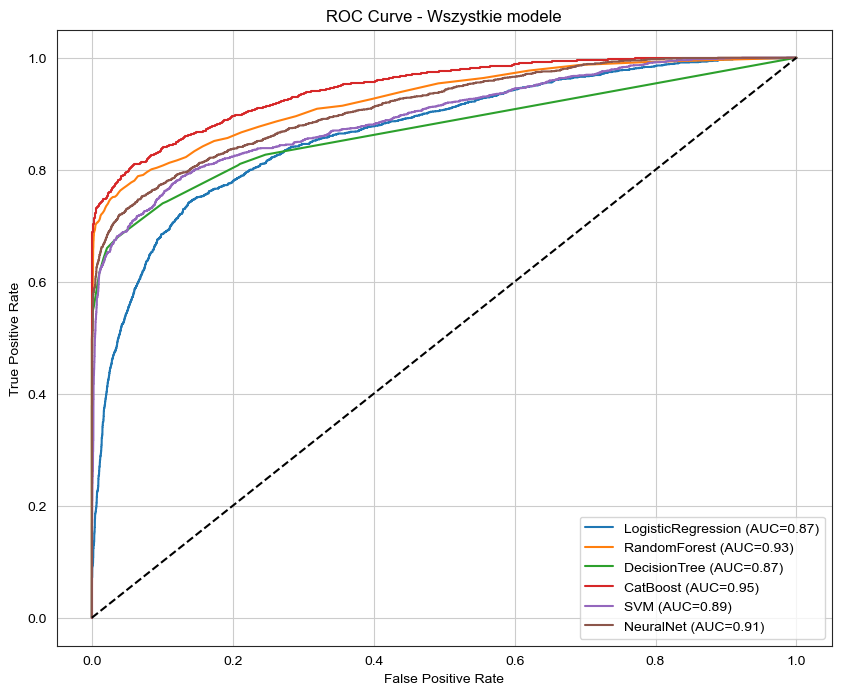

In [ ]:
#24 Zbiorczy wykres ROC
plt.figure(figsize=(10, 8))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, res['proba']):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Wszystkie modele")
plt.legend()
plt.grid()
plt.show()

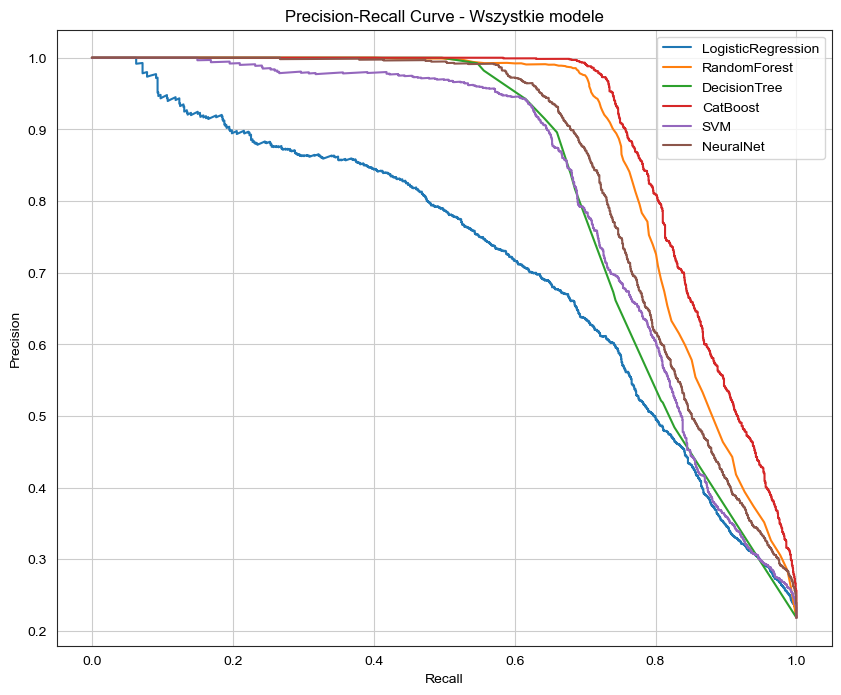

In [ ]:
#25 Zbiorczy wykres Precision-Recall
plt.figure(figsize=(10, 8))
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['proba'])
    plt.plot(recall, precision, label=f"{name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Wszystkie modele")
plt.legend()
plt.grid()
plt.show()